<div style="background:linear-gradient(135deg,#1a1a2e 0%,#16213e 50%,#0f3460 100%);
     padding:60px 40px;border-radius:16px;text-align:center;">
  <h1 style="color:#e94560;font-size:2.5em;font-weight:900;letter-spacing:2px;">
    ZONIER TARIFAIRE AUTOMOBILE
  </h1>
  <h2 style="color:#a8dadc;font-size:1.35em;font-weight:400;margin-bottom:24px;">
    Modélisation du Score de Sinistralité par Commune — France 2023
  </h2>
  <hr style="border:1px solid #e94560;width:55%;margin:16px auto;">
  <p style="color:#fff;font-size:1.05em;line-height:2.0;">
    <b>Matières :</b> PySpark &nbsp;·&nbsp; Analyse de Données II &nbsp;·&nbsp;
    Machine Learning / Optimisation Stochastique<br>
    <b>Parcours :</b> M2 Actuariat — Data Science &nbsp;&nbsp;|&nbsp;&nbsp;
    <b>Année :</b> 2025-2026
  </p>
  <hr style="border:1px solid #e94560;width:55%;margin:16px auto;">
  <p style="color:#aaa;font-size:0.88em;">
    Enseignants : Anis Matoussi · Youssef Esstafa · Wajd Meskini · Samir Ben Hariz
  </p>
</div>

---
## Table des matières

| # | Section | Matière |
|---|---------|---------|
| **1** | [Installation & Imports](#install) | — |
| **2** | [Lecture des données BAAC 2023](#etape1) | PySpark |
| **3** | [Jointure — 1 ligne = 1 accident](#etape2) | PySpark |
| **4** | [Indicateurs de risque par accident](#etape3) | PySpark |
| **5** | [Agrégation par commune — 1 ligne = 1 commune](#etape4) | PySpark |
| **6** | [Visualisation exploratoire](#etape5) | PySpark |
| **7** | [Données INSEE & enrichissement](#etape6) | PySpark |
| **8** | [Variable cible : score de sinistralité](#etape7) | PySpark |
| **9** | [Corrélations & ACP](#etape8) | Analyse de Données II |
| **10** | [Régressions linéaire & logistique](#etape9) | Analyse de Données II |
| **11** | [Optimisation stochastique (GD / SGD)](#etape10) | ML / Optimisation |
| **12** | [Modèles de classification (7 algorithmes)](#etape11) | ML / Optimisation |
| **13** | [Hyperparamètres, CV, Explicabilité, RFE](#etape12) | ML / Optimisation |
| **14** | [Construction du Zonier Tarifaire](#etape13) | Synthèse |

> **Note :** les trois parties sont notées séparément. La partie PySpark (étapes 1–8) tourne sur Google Colab. Le passage à pandas se fait via `.toPandas()` avant les étapes de modélisation.
---

---
<a id='install'></a>
<div style="background:#0f3460;padding:14px 24px;border-radius:8px;border-left:5px solid #e94560;">
<h3 style="color:#fff;margin:0;">Installation & Imports</h3>
</div>

In [ ]:
# Sur Google Colab, décommenter la ligne suivante :
#!pip install pyspark -q

import warnings
warnings.filterwarnings('ignore')

# ── PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType, StringType
from pyspark.sql.window import Window

# ── Data science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Machine Learning (sklearn)
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def watermark(ax, text="M2 Actuariat 2025-2026"):
    ax.text(0.99, 0.01, text, transform=ax.transAxes,
            fontsize=8, color='gray', alpha=0.5,
            ha='right', va='bottom', style='italic')

print("Tous les imports OK.")

Tous les imports OK.


---
<a id='etape1'></a>
<div style="background:linear-gradient(90deg,#e94560,#c23152);padding:16px 26px;border-radius:10px;">
<h2 style="color:#fff;margin:0;">PARTIE 1 — Préparation des données (PySpark)</h2>
<p style="color:#ffcccc;margin:4px 0 0 0;font-size:0.9em;">
Matière : PySpark · Étapes 1 à 6 · Données BAAC 2023 + INSEE
</p>
</div>

### Étape 1 — Initialisation Spark & Lecture des données BAAC 2023

Les données proviennent de [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere-annees-de-2005-a-2022/).

**4 fichiers sources :**

| Fichier | Clé | Contenu |
|---------|-----|---------|
| `caract-2023.csv` | `Num_Acc` | Date, heure, commune, météo |
| `lieux-2023.csv` | `Num_Acc` | Type de route, état de surface |
| `vehicules-2023.csv` | `Num_Acc` | Type de véhicule |
| `usagers-2023.csv` | `Num_Acc` | **Gravité `grav`**, profil usager |

> La colonne `com` contient déjà le code INSEE complet à 5 chiffres — pas besoin de concaténer avec `dep`.

In [ ]:
# Initialisation de la session Spark
spark = SparkSession.builder \
    .appName("ZonierTarifaireAuto") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version : {spark.version}")

# ── Lecture des 4 fichiers BAAC 2023
# Séparateur point-virgule, première ligne = en-tête, inférence des types automatique
# Sur Colab avec Google Drive : remplacer le chemin par '/content/drive/MyDrive/...'

DATA_PATH = "/content/Data/"   # adapter selon votre environnement

df_carac = spark.read.csv(DATA_PATH + "caract-2023.csv",    sep=";", header=True, inferSchema=True)
df_lieux = spark.read.csv(DATA_PATH + "lieux-2023.csv",     sep=";", header=True, inferSchema=True)
df_vehi  = spark.read.csv(DATA_PATH + "vehicules-2023.csv", sep=";", header=True, inferSchema=True)
df_usag  = spark.read.csv(DATA_PATH + "usagers-2023.csv",   sep=";", header=True, inferSchema=True)

print("\nDimensions des fichiers sources :")
print(f"  caracteristiques : {df_carac.count():>7,} lignes x {len(df_carac.columns):>2} colonnes")
print(f"  lieux            : {df_lieux.count():>7,} lignes x {len(df_lieux.columns):>2} colonnes")
print(f"  vehicules        : {df_vehi.count():>7,} lignes x {len(df_vehi.columns):>2} colonnes")
print(f"  usagers          : {df_usag.count():>7,} lignes x {len(df_usag.columns):>2} colonnes")

print("\nSchéma de caracteristiques :")
df_carac.printSchema()

Spark version : 4.0.2

Dimensions des fichiers sources :
  caracteristiques :  54,822 lignes x 15 colonnes
  lieux            :  70,860 lignes x 18 colonnes
  vehicules        :  93,585 lignes x 11 colonnes
  usagers          : 125,789 lignes x 16 colonnes

Schéma de caracteristiques :
root
 |-- Num_Acc: long (nullable = true)
 |-- jour: integer (nullable = true)
 |-- mois: integer (nullable = true)
 |-- an: integer (nullable = true)
 |-- hrmn: timestamp (nullable = true)
 |-- lum: double (nullable = true)
 |-- dep: string (nullable = true)
 |-- com: string (nullable = true)
 |-- agg: integer (nullable = true)
 |-- int: double (nullable = true)
 |-- atm: double (nullable = true)
 |-- col: double (nullable = true)
 |-- adr: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- long: string (nullable = true)



In [ ]:
# Aperçu des données brutes
print("=== caracteristiques (5 premières lignes) ===")
df_carac.select('Num_Acc','jour','mois','hrmn','dep','com','agg','atm').show(5)

print("=== lieux ===")
df_lieux.select('Num_Acc','catr','surf').show(5)

print("=== usagers (variable cible grav) ===")
df_usag.select('Num_Acc','grav','catu','sexe','an_nais').show(5)

print("=== Distribution de grav ===")
df_usag.groupBy('grav').count().orderBy('grav').show()
# grav : 1=indemne, 2=tué, 3=hospitalisé, 4=blessé léger, -1=valeur manquante

=== caracteristiques (5 premières lignes) ===
+------------+----+----+-------------------+---+-----+---+---+
|     Num_Acc|jour|mois|               hrmn|dep|  com|agg|atm|
+------------+----+----+-------------------+---+-----+---+---+
|202300000001|   7|   5|2026-05-14 06:00:00| 75|75101|  2|2.0|
|202300000002|   7|   5|2026-05-14 05:30:00| 94|94080|  2|3.0|
|202300000003|   7|   5|2026-05-14 20:50:00| 94|94022|  2|2.0|
|202300000004|   6|   5|2026-05-14 23:57:00| 94|94078|  2|3.0|
|202300000005|   7|   5|2026-05-14 00:50:00| 94|94068|  2|3.0|
+------------+----+----+-------------------+---+-----+---+---+
only showing top 5 rows
=== lieux ===
+------------+----+----+
|     Num_Acc|catr|surf|
+------------+----+----+
|202300000001|   4| 2.0|
|202300000001|   4| 2.0|
|202300000002|   3| 2.0|
|202300000003|   3| 2.0|
|202300000003|   3| 2.0|
+------------+----+----+
only showing top 5 rows
=== usagers (variable cible grav) ===
+------------+----+----+----+-------+
|     Num_Acc|grav|catu|

### Étape 2 — Jointure des tables — 1 ligne = 1 accident

**Stratégie de jointure :**

```
df_carac  ──(Num_Acc)──► df_lieux_agg   [1:1 après agrégation de lieux]
df_carac  ──(Num_Acc)──► df_usag_agg    [1:N → agrégation par accident]
df_carac  ──(Num_Acc)──► df_vehi_agg    [1:N → agrégation par accident]
```

**Points critiques :**
- `lieux` contient **plusieurs lignes par accident** (plusieurs voies impliquées) → on prend la première ligne par accident
- `grav` est dans `usagers` → agrégation par `Num_Acc` pour comptage par type
- `grav = -1` est une valeur manquante dans les données source → à filtrer

In [ ]:
# ---------------------------------------------------------------------------
# Agrégation de lieux : plusieurs voies par accident -> on garde la 1ère
# On utilise first() pour le type de route dominant
# ---------------------------------------------------------------------------

# Vérification : combien de lignes par accident dans lieux ?
from pyspark.sql.window import Window
lieux_counts = df_lieux.groupBy('Num_Acc').count()
print("Lignes par accident dans lieux (distribution) :")
lieux_counts.groupBy('count').count().orderBy('count').show()

# Agrégation : first() pour les variables catégorielles de la voie principale
df_lieux_agg = df_lieux.groupBy('Num_Acc').agg(
    F.first('catr').alias('catr'),   # type de route (autoroute, nationale, etc.)
    F.first('surf').alias('surf'),   # état de surface
    F.first('infra').alias('infra'), # infrastructure
    F.first('situ').alias('situ'),   # situation de l'accident
    F.avg('vma').alias('vma_moy'),   # vitesse max autorisée (moyenne)
)

# Indicateur autoroute depuis lieux
df_lieux_agg = df_lieux_agg.withColumn(
    'is_autoroute', F.when(F.col('catr') == 1, 1).otherwise(0)
)

print(f"\ndf_lieux_agg : {df_lieux_agg.count():,} lignes (1 par accident)")

Lignes par accident dans lieux (distribution) :
+-----+-----+
|count|count|
+-----+-----+
|    1|38952|
|    2|15715|
|    3|  143|
|    4|   11|
|    5|    1|
+-----+-----+


df_lieux_agg : 54,822 lignes (1 par accident)


In [ ]:
# ---------------------------------------------------------------------------
# Agrégation de usagers par Num_Acc
# La gravité est au niveau USAGER -> on agrège au niveau ACCIDENT
# ---------------------------------------------------------------------------

# Filtrage grav = -1 (valeur manquante dans les données BAAC)
df_usag_clean = df_usag.filter(F.col('grav') != -1)
print(f"Usagers avant filtrage : {df_usag.count():,}")
print(f"Usagers après filtrage : {df_usag_clean.count():,}")

# One-Hot Encoding de grav + comptage par type (somme par accident)
df_usag_agg = df_usag_clean.groupBy('Num_Acc').agg(
    F.count('grav').alias('nb_usagers'),
    # OHE gravité — somme = nombre d'usagers par catégorie
    F.sum(F.when(F.col('grav') == 1, 1).otherwise(0)).alias('grav_indemne'),
    F.sum(F.when(F.col('grav') == 4, 1).otherwise(0)).alias('grav_bless_leger'),
    F.sum(F.when(F.col('grav') == 3, 1).otherwise(0)).alias('grav_hosp'),
    F.sum(F.when(F.col('grav') == 2, 1).otherwise(0)).alias('grav_tue'),
    # Alias redondants utilisés dans le score
    F.sum(F.when(F.col('grav') == 2, 1).otherwise(0)).alias('nb_tues'),
    F.sum(F.when(F.col('grav') == 3, 1).otherwise(0)).alias('nb_hosp'),
    F.sum(F.when(F.col('grav') == 4, 1).otherwise(0)).alias('nb_bless_leger'),
    F.sum(F.when(F.col('grav') == 1, 1).otherwise(0)).alias('nb_indemnes'),
)

print(f"\ndf_usag_agg : {df_usag_agg.count():,} lignes (1 par accident)")
df_usag_agg.show(3)

Usagers avant filtrage : 125,789
Usagers après filtrage : 125,671

df_usag_agg : 54,822 lignes (1 par accident)
+------------+----------+------------+----------------+---------+--------+-------+-------+--------------+-----------+
|     Num_Acc|nb_usagers|grav_indemne|grav_bless_leger|grav_hosp|grav_tue|nb_tues|nb_hosp|nb_bless_leger|nb_indemnes|
+------------+----------+------------+----------------+---------+--------+-------+-------+--------------+-----------+
|202300000523|         2|           1|               1|        0|       0|      0|      0|             1|          1|
|202300000647|         2|           1|               1|        0|       0|      0|      0|             1|          1|
|202300000832|         2|           1|               1|        0|       0|      0|      0|             1|          1|
+------------+----------+------------+----------------+---------+--------+-------+-------+--------------+-----------+
only showing top 3 rows


In [ ]:
# ---------------------------------------------------------------------------
# Agrégation de vehicules par Num_Acc
# ---------------------------------------------------------------------------

# Indicateur 2-roues (catv : motos, scooters, vélos)
CATV_2ROUES = [1, 2, 30, 31, 32, 33, 34, 35, 36, 37, 80]
df_vehi = df_vehi.withColumn(
    'is_2roues', F.when(F.col('catv').isin(CATV_2ROUES), 1).otherwise(0)
)

df_vehi_agg = df_vehi.groupBy('Num_Acc').agg(
    F.count('id_vehicule').alias('nb_vehicules'),
    F.sum('is_2roues').alias('nb_2roues'),
)

print(f"df_vehi_agg : {df_vehi_agg.count():,} lignes (1 par accident)")

# ---------------------------------------------------------------------------
# JOINTURE FINALE : 1 ligne = 1 accident
# ---------------------------------------------------------------------------
df_acc = df_carac \
    .join(df_lieux_agg, on='Num_Acc', how='left') \
    .join(df_usag_agg,  on='Num_Acc', how='left') \
    .join(df_vehi_agg,  on='Num_Acc', how='left')

# Remplacement des nulls par 0
df_acc = df_acc.fillna(0)

print(f"\nDataset accidents final : {df_acc.count():,} lignes x {len(df_acc.columns)} colonnes")
print("\nAperçu :")
df_acc.select('Num_Acc','com','nb_tues','nb_hosp','grav_bless_leger','nb_vehicules').show(5)

df_vehi_agg : 54,822 lignes (1 par accident)

Dataset accidents final : 54,822 lignes x 32 colonnes

Aperçu :
+------------+-----+-------+-------+----------------+------------+
|     Num_Acc|  com|nb_tues|nb_hosp|grav_bless_leger|nb_vehicules|
+------------+-----+-------+-------+----------------+------------+
|202300000001|75101|      0|      0|               1|           1|
|202300000002|94080|      0|      1|               0|           1|
|202300000003|94022|      0|      1|               0|           2|
|202300000004|94078|      0|      0|               1|           3|
|202300000005|94068|      0|      0|               1|           2|
+------------+-----+-------+-------+----------------+------------+
only showing top 5 rows


### Étape 3 — Extraction des indicateurs de risque

On crée des **variables binaires (0/1)** capturant les circonstances de chaque accident. Elles seront moyennées à l'étape suivante pour obtenir des **proportions par commune**.

| Indicateur | Critère | Justification actuarielle |
|-----------|---------|--------------------------|
| `is_nuit` | 23h–6h | Visibilité réduite, fatigue |
| `is_autoroute` | catr = 1 | Accidents transit, vitesse élevée |
| `is_hiver` | mois 12/1/2 | Chaussée glissante |
| `is_agglo` | agg = 2 | Densité piétons/cyclistes |
| `is_meteo_anormale` | atm ≠ 1 | Pluie, neige, brouillard |
| `is_weekend` | jour 6 ou 7 | Conduite festive |
| `is_multi_vehicule` | nb_vehicules > 1 | Accidents plus graves |

In [ ]:
# ---------------------------------------------------------------------------
# Extraction de l'heure depuis la colonne hrmn (format timestamp)
# PySpark a parsé hrmn en timestamp -> on extrait l'heure avec F.hour()
# ---------------------------------------------------------------------------
df_acc = df_acc.withColumn('heure', F.hour('hrmn'))

# Indicateurs de risque
df_acc = df_acc \
    .withColumn('is_nuit',
                F.when((F.col('heure') >= 23) | (F.col('heure') < 6), 1).otherwise(0)) \
    .withColumn('is_hiver',
                F.when(F.col('mois').isin(12, 1, 2), 1).otherwise(0)) \
    .withColumn('is_agglo',
                F.when(F.col('agg') == 2, 1).otherwise(0)) \
    .withColumn('is_meteo_anormale',
                F.when(F.col('atm').cast(DoubleType()) != 1.0, 1).otherwise(0)) \
    .withColumn('is_weekend',
                F.when(F.col('jour').isin(6, 7), 1).otherwise(0)) \
    .withColumn('is_multi_vehicule',
                F.when(F.col('nb_vehicules') > 1, 1).otherwise(0)) \
    .withColumn('code_commune',
                F.col('com').cast(StringType()))

# Résumé
print("Proportions nationales des indicateurs :")
print(f"  {'Indicateur':<22}  {'Proportion':>10}")
print("  " + "-" * 35)
for ind in ['is_nuit','is_autoroute','is_hiver','is_agglo',
            'is_meteo_anormale','is_weekend','is_multi_vehicule']:
    if ind in df_acc.columns:
        prop = df_acc.agg(F.avg(ind)).collect()[0][0]
        print(f"  {ind:<22}  {prop:>10.3f}")

Proportions nationales des indicateurs :
  Indicateur              Proportion
  -----------------------------------
  is_nuit                      0.110
  is_autoroute                 0.093
  is_hiver                     0.222
  is_agglo                     0.626
  is_meteo_anormale            0.220
  is_weekend                   0.073
  is_multi_vehicule            0.621


### Étape 4 — Agrégation par commune — 1 ligne = 1 commune

**Choix d'agrégation justifiés dans le rapport :**
- Colonnes `grav_*` → **`sum`** : on veut le nombre total d'usagers par catégorie de gravité
- Indicateurs de risque → **`avg`** : on obtient une proportion comparable entre communes
- `nb_vehicules`, `nb_2roues` → **`avg`** : valeur moyenne par accident dans la commune

In [ ]:
# ---------------------------------------------------------------------------
# Agrégation par commune (groupBy + agg PySpark)
# ---------------------------------------------------------------------------
df_comm = df_acc.groupBy('code_commune').agg(
    # Volume sinistres
    F.count('Num_Acc').alias('nb_accidents'),

    # One-Hot gravité (somme = nombre d'usagers par type)
    F.sum('grav_indemne').alias('grav_indemne'),
    F.sum('grav_bless_leger').alias('grav_bless_leger'),
    F.sum('grav_hosp').alias('grav_hosp'),
    F.sum('grav_tue').alias('grav_tue'),

    # Totaux utilisés dans le score
    F.sum('nb_tues').alias('nb_tues'),
    F.sum('nb_hosp').alias('nb_hosp'),
    F.sum('nb_bless_leger').alias('nb_bless_leger'),
    F.sum('nb_indemnes').alias('nb_indemnes'),

    # Indicateurs de risque (moyenne = proportion dans la commune)
    F.avg('is_nuit').alias('prop_nuit'),
    F.avg('is_autoroute').alias('prop_autoroute'),
    F.avg('is_hiver').alias('prop_hiver'),
    F.avg('is_agglo').alias('prop_agglo'),
    F.avg('is_meteo_anormale').alias('prop_meteo_anormale'),
    F.avg('is_weekend').alias('prop_weekend'),
    F.avg('is_multi_vehicule').alias('prop_multi_vehicule'),

    # Moyennes numériques
    F.avg('nb_vehicules').alias('nb_vehicules_moy'),
    F.avg('nb_2roues').alias('nb_2roues_moy'),
)

# Valeurs manquantes -> 0
df_comm = df_comm.fillna(0)

# Détection des communes de transit
# Critère : prop_autoroute > Q85 ET nb_accidents > médiane
# Ces communes ont une sinistralité élevée due au trafic de passage (pas aux résidents)
q85_autoroute = df_comm.approxQuantile('prop_autoroute', [0.85], 0.01)[0]
mediane_acc   = df_comm.approxQuantile('nb_accidents',   [0.50], 0.01)[0]

df_comm = df_comm.withColumn(
    'is_transit',
    F.when(
        (F.col('prop_autoroute') > q85_autoroute) &
        (F.col('nb_accidents')   > mediane_acc),
        1
    ).otherwise(0)
)

n_communes = df_comm.count()
n_transit  = df_comm.filter(F.col('is_transit') == 1).count()

print(f"Dataset communes : {n_communes:,} communes")
print(f"Communes de transit identifiées : {n_transit:,}")
print(f"  Seuil prop_autoroute (Q85) : {q85_autoroute:.3f}")
print(f"  Seuil nb_accidents (médiane): {mediane_acc:.0f}")
print("\nAperçu :")
df_comm.select('code_commune','nb_accidents','grav_tue','prop_nuit',
               'prop_autoroute','is_transit').show(5)

Dataset communes : 11,311 communes
Communes de transit identifiées : 903
  Seuil prop_autoroute (Q85) : 0.000
  Seuil nb_accidents (médiane): 1

Aperçu :
+------------+------------+--------+--------------------+--------------+----------+
|code_commune|nb_accidents|grav_tue|           prop_nuit|prop_autoroute|is_transit|
+------------+------------+--------+--------------------+--------------+----------+
|       49307|           4|       1|                 0.0|          0.25|         1|
|       92072|          62|       0| 0.16129032258064516|           0.0|         0|
|       45273|           1|       0|                 0.0|           0.0|         0|
|       02527|           1|       0|                 0.0|           0.0|         0|
|       91421|          27|       0|0.037037037037037035|           0.0|         0|
+------------+------------+--------+--------------------+--------------+----------+
only showing top 5 rows


### Étape 5 — Visualisation exploratoire

On convertit le DataFrame Spark en Pandas pour les visualisations matplotlib/seaborn.

> `df_comm_pd = df_comm.toPandas()` — opération unique, résultat mis en cache localement.

In [ ]:
# Conversion vers Pandas pour les visualisations
# Cette opération est faite UNE SEULE FOIS et le résultat est conservé en mémoire
df_comm_pd = df_comm.toPandas()

print(f"DataFrame communes (pandas) : {df_comm_pd.shape}")
df_comm_pd.head(3)

DataFrame communes (pandas) : (11311, 20)


,code_commune,nb_accidents,grav_indemne,grav_bless_leger,grav_hosp,grav_tue,nb_tues,nb_hosp,nb_bless_leger,nb_indemnes,prop_nuit,prop_autoroute,prop_hiver,prop_agglo,prop_meteo_anormale,prop_weekend,prop_multi_vehicule,nb_vehicules_moy,nb_2roues_moy,is_transit
0,49307,4,5,0,3,1,1,3,0,5,0.00000,0.25,0.50000,0.000000,0.500000,0.000000,0.500000,1.500000,0.500000,1
1,92072,62,68,73,3,0,0,3,73,68,0.16129,0.00,0.16129,0.629032,0.290323,0.048387,0.580645,1.693548,0.516129,0
2,45273,1,2,0,1,0,0,1,0,2,0.00000,0.00,0.00000,1.000000,0.000000,0.000000,1.000000,2.000000,1.000000,0


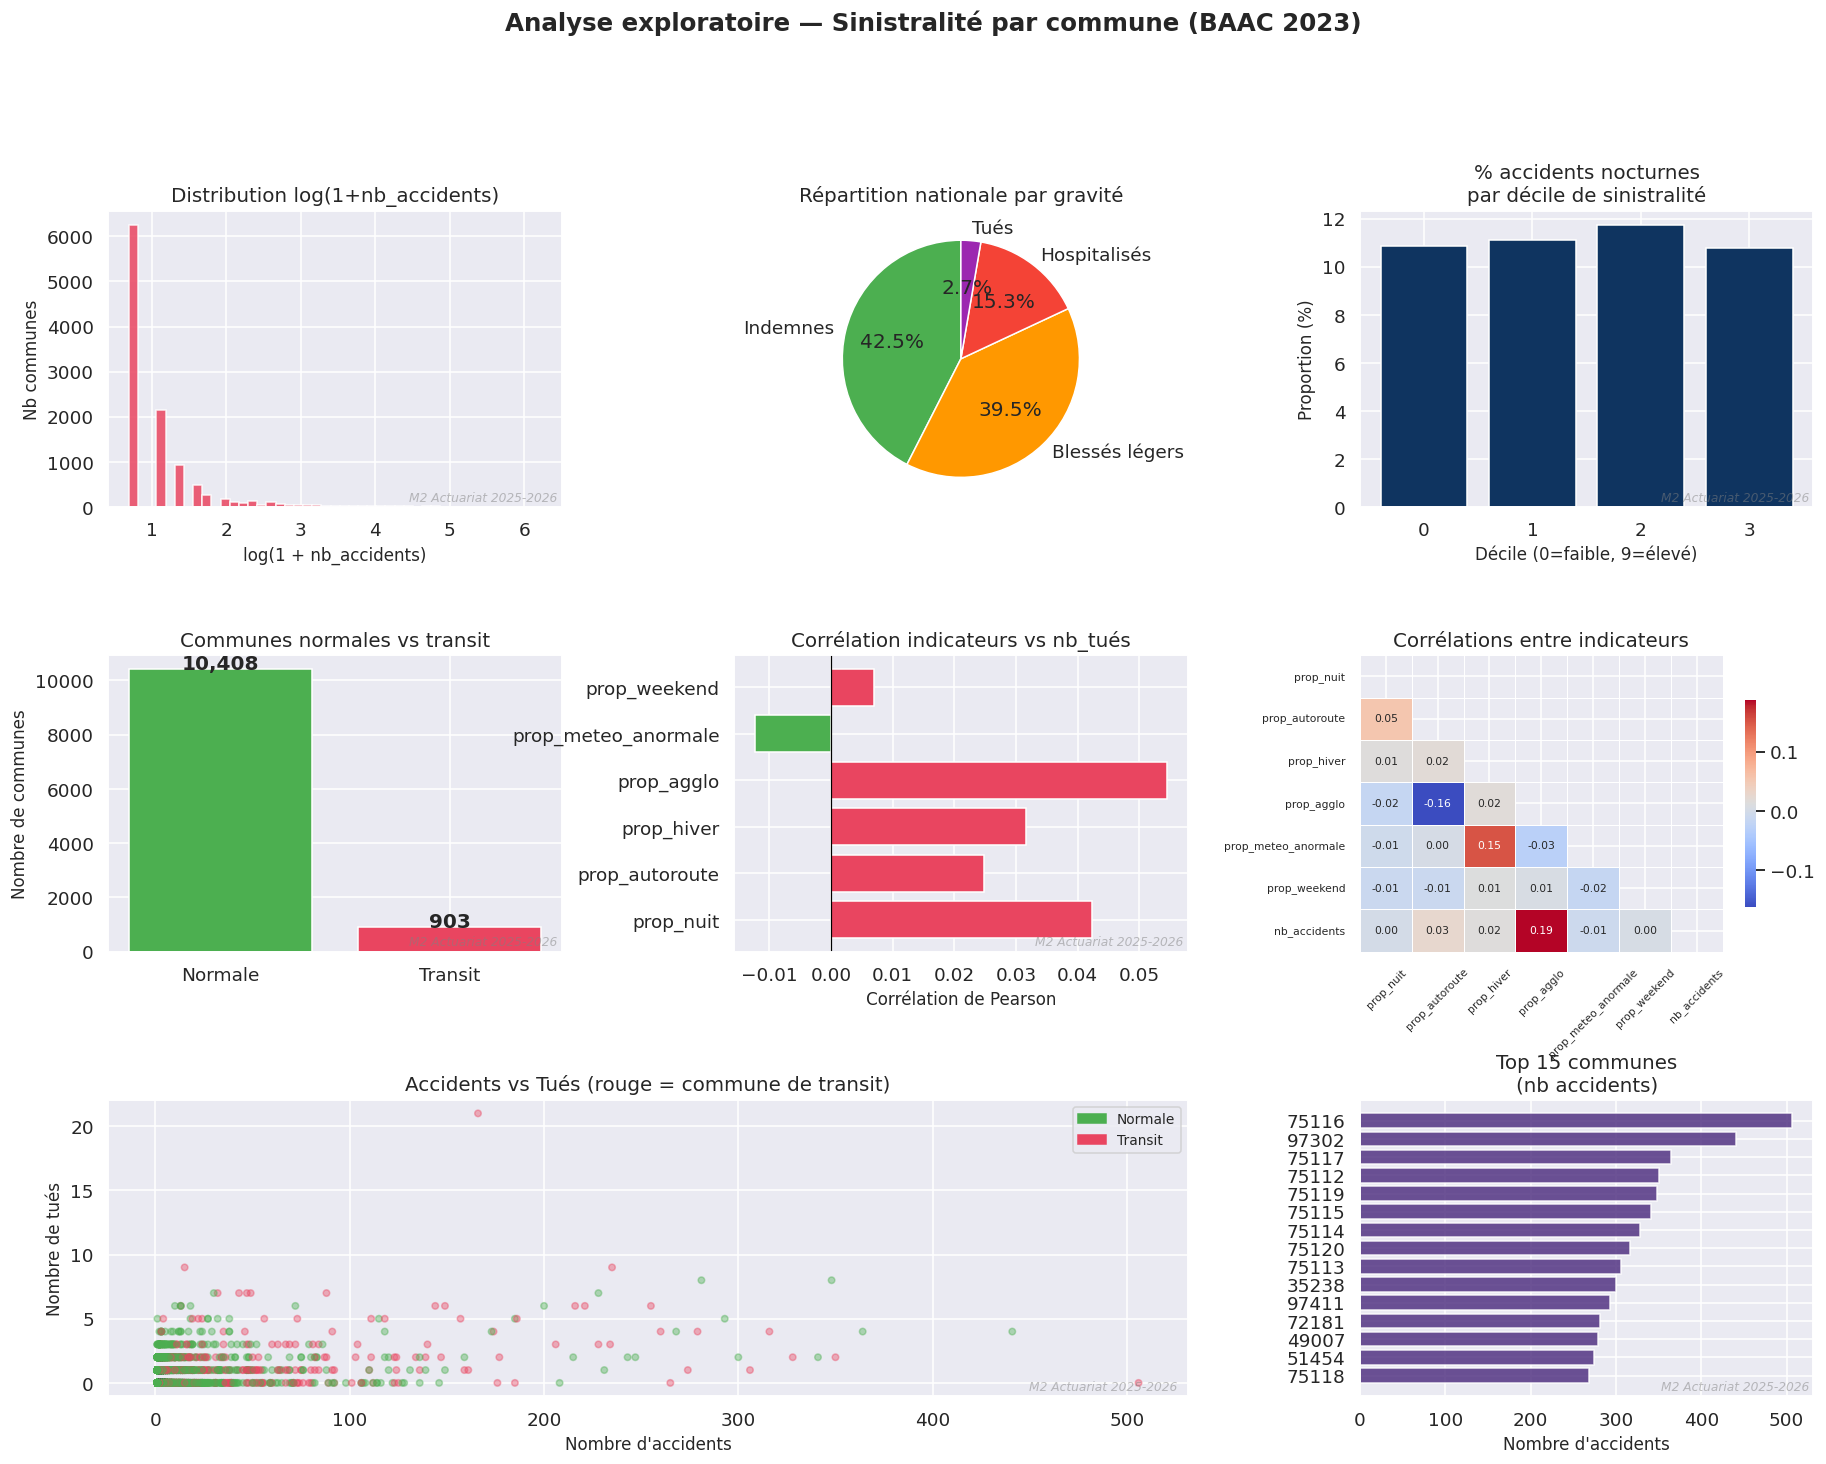

In [ ]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle("Analyse exploratoire — Sinistralité par commune (BAAC 2023)",
             fontsize=16, fontweight='bold', y=1.01)
gs = GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

# 1. Distribution nb_accidents (log)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(np.log1p(df_comm_pd['nb_accidents']), bins=45,
         color='#e94560', edgecolor='white', alpha=0.85)
ax1.set_title("Distribution log(1+nb_accidents)")
ax1.set_xlabel("log(1 + nb_accidents)")
ax1.set_ylabel("Nb communes")
watermark(ax1)

# 2. Répartition par gravité
ax2 = fig.add_subplot(gs[0, 1])
grav_vals   = [df_comm_pd['grav_indemne'].sum(), df_comm_pd['grav_bless_leger'].sum(),
               df_comm_pd['grav_hosp'].sum(),    df_comm_pd['grav_tue'].sum()]
grav_labels = ['Indemnes', 'Blessés légers', 'Hospitalisés', 'Tués']
ax2.pie(grav_vals, labels=grav_labels, autopct='%1.1f%%',
        colors=['#4caf50','#ff9800','#f44336','#9c27b0'], startangle=90)
ax2.set_title("Répartition nationale par gravité")

# 3. Proportion nocturne par décile de sinistralité
ax3 = fig.add_subplot(gs[0, 2])
df_comm_pd['decile'] = pd.qcut(df_comm_pd['nb_accidents'], 10, labels=False, duplicates='drop')
nuit_dec = df_comm_pd.groupby('decile')['prop_nuit'].mean()
ax3.bar(nuit_dec.index, nuit_dec.values * 100, color='#0f3460', edgecolor='white')
ax3.set_title("% accidents nocturnes\npar décile de sinistralité")
ax3.set_xlabel("Décile (0=faible, 9=élevé)")
ax3.set_ylabel("Proportion (%)")
watermark(ax3)

# 4. Communes transit vs normales
ax4 = fig.add_subplot(gs[1, 0])
vc = df_comm_pd['is_transit'].value_counts().reindex([0,1]).fillna(0)
ax4.bar(['Normale','Transit'], vc.values, color=['#4caf50','#e94560'], edgecolor='white')
ax4.set_title("Communes normales vs transit")
ax4.set_ylabel("Nombre de communes")
for i, v in enumerate(vc.values):
    ax4.text(i, v+5, f"{int(v):,}", ha='center', fontweight='bold')
watermark(ax4)

# 5. Corrélation indicateurs vs tués
ax5 = fig.add_subplot(gs[1, 1])
indic_list = ['prop_nuit','prop_autoroute','prop_hiver',
              'prop_agglo','prop_meteo_anormale','prop_weekend']
corrs = [df_comm_pd[ind].corr(df_comm_pd['nb_tues']) for ind in indic_list]
ax5.barh(indic_list, corrs,
         color=['#e94560' if c > 0 else '#4caf50' for c in corrs], edgecolor='white')
ax5.axvline(0, color='black', linewidth=0.8)
ax5.set_title("Corrélation indicateurs vs nb_tués")
ax5.set_xlabel("Corrélation de Pearson")
watermark(ax5)

# 6. Heatmap corrélations
ax6 = fig.add_subplot(gs[1, 2])
corr_m = df_comm_pd[indic_list + ['nb_accidents']].corr()
mask   = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, ax=ax6, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
ax6.set_title("Corrélations entre indicateurs")
ax6.tick_params(axis='x', rotation=45, labelsize=7)
ax6.tick_params(axis='y', labelsize=7)

# 7. Scatter accidents vs tués
ax7 = fig.add_subplot(gs[2, 0:2])
sc_colors = df_comm_pd['is_transit'].map({0:'#4caf50', 1:'#e94560'})
ax7.scatter(df_comm_pd['nb_accidents'], df_comm_pd['nb_tues'],
            c=sc_colors, alpha=0.4, s=18)
ax7.set_xlabel("Nombre d'accidents")
ax7.set_ylabel("Nombre de tués")
ax7.set_title("Accidents vs Tués (rouge = commune de transit)")
ax7.legend(handles=[mpatches.Patch(color='#4caf50', label='Normale'),
                    mpatches.Patch(color='#e94560', label='Transit')], fontsize=9)
watermark(ax7)

# 8. Top 15 communes les plus accidentées
ax8 = fig.add_subplot(gs[2, 2])
top15 = df_comm_pd.nlargest(15, 'nb_accidents').sort_values('nb_accidents')
ax8.barh(top15['code_commune'], top15['nb_accidents'],
         color='#533483', edgecolor='white', alpha=0.85)
ax8.set_title("Top 15 communes\n(nb accidents)")
ax8.set_xlabel("Nombre d'accidents")
watermark(ax8)

plt.tight_layout()
plt.show()

### Étape 6 — Données INSEE & enrichissement

**Sources recommandées :**
- [Base comparateur communes](https://www.insee.fr/fr/statistiques/2521169) → population, ménages, superficie
- [Populations par sexe/âge](https://www.insee.fr/fr/statistiques/1893204)
- [Salaires DADS 2023](https://www.insee.fr/fr/statistiques/2021266)

**Chargement en PySpark :**
```python
df_pop = spark.read.csv("base-cc-comparateur.csv", sep=";", header=True, inferSchema=True)
df_comm = df_comm.join(df_pop.select('CODGEO','P23_POP','SUPERF'),
                        df_comm.code_commune == df_pop.CODGEO, how='left')
```

> Pour ce notebook, des données socio-économiques **synthétiques représentatives** sont générées afin de faire tourner l'ensemble du pipeline. En production : remplacer par les vrais fichiers INSEE.

In [ ]:
# ---------------------------------------------------------------------------
# Données INSEE réelles (communes) + fallback simulé
# ---------------------------------------------------------------------------
from pathlib import Path

base_path = Path('.')
comparateur_xlsx = base_path / 'base_cc_comparateur.xlsx'
age_xlsx         = base_path / 'BTS_SEX_AGE_2023_FR.xlsx'

use_real_insee = comparateur_xlsx.exists() and age_xlsx.exists()

if use_real_insee:
    print("Chargement des données INSEE réelles…")

    # 1) Variables structurelles communales (population, ménages, superficie)
    df_pop_pd = pd.read_excel(comparateur_xlsx, dtype={'CODGEO': str})

    # Harmonisation minimale des noms de colonnes
    colmap_pop = {
        'P23_POP': 'population',
        'P23_MEN': 'nb_menages',
        'MEN': 'nb_menages',
        'NB_MENAGES': 'nb_menages',
        'SUPERF': 'superficie_km2',
        'SUPERFICIE': 'superficie_km2',
    }
    df_pop_pd = df_pop_pd.rename(columns={k: v for k, v in colmap_pop.items() if k in df_pop_pd.columns})

    keep_pop = [c for c in ['CODGEO', 'population', 'nb_menages', 'superficie_km2'] if c in df_pop_pd.columns]
    df_pop_pd = df_pop_pd[keep_pop].copy()

    # 2) Structure d'âge communale (BTS_SEX_AGE_2023_FR)
    df_age_pd = pd.read_excel(age_xlsx, dtype={'CODGEO': str})

    # Colonnes attendues (souvent POP_15_29 / POP_60P / POP_TOT)
    candidates = {
        'pop_15_29': ['POP_15_29', 'P15_29', 'AGE_15_29'],
        'pop_60plus': ['POP_60P', 'POP_60_PLUS', 'P60P', 'AGE_60P'],
        'pop_totale': ['POP_TOT', 'POP_TOTAL', 'P23_POP', 'POP'],
    }

    def first_existing(cols, choices):
        for c in choices:
            if c in cols:
                return c
        return None

    c_15_29 = first_existing(df_age_pd.columns, candidates['pop_15_29'])
    c_60p   = first_existing(df_age_pd.columns, candidates['pop_60plus'])
    c_tot   = first_existing(df_age_pd.columns, candidates['pop_totale'])

    age_cols = ['CODGEO'] + [c for c in [c_15_29, c_60p, c_tot] if c is not None]
    df_age_pd = df_age_pd[age_cols].copy()

    if c_15_29 is not None:
        df_age_pd = df_age_pd.rename(columns={c_15_29: 'pop_15_29'})
    if c_60p is not None:
        df_age_pd = df_age_pd.rename(columns={c_60p: 'pop_60plus'})
    if c_tot is not None:
        df_age_pd = df_age_pd.rename(columns={c_tot: 'pop_totale'})

    # Jointure INSEE côté pandas puis enrichissement du dataset communal
    df_insee_pd = df_pop_pd.merge(df_age_pd, on='CODGEO', how='left')
    df_insee_pd = df_insee_pd.rename(columns={'CODGEO': 'code_commune'})

    # Calcul des parts d'âge (en %) si possible
    if {'pop_15_29', 'pop_totale'}.issubset(df_insee_pd.columns):
        df_insee_pd['part_pop_15_29'] = np.where(
            df_insee_pd['pop_totale'] > 0,
            df_insee_pd['pop_15_29'] / df_insee_pd['pop_totale'] * 100,
            np.nan,
        )

    if {'pop_60plus', 'pop_totale'}.issubset(df_insee_pd.columns):
        df_insee_pd['part_pop_60plus'] = np.where(
            df_insee_pd['pop_totale'] > 0,
            df_insee_pd['pop_60plus'] / df_insee_pd['pop_totale'] * 100,
            np.nan,
        )

    # Fallback doux pour variables non présentes dans les fichiers livrés
    if 'salaire_net_horaire_moyen' not in df_insee_pd.columns:
        df_insee_pd['salaire_net_horaire_moyen'] = np.nan
    if 'taux_chomage' not in df_insee_pd.columns:
        df_insee_pd['taux_chomage'] = np.nan
    if 'part_cadres' not in df_insee_pd.columns:
        df_insee_pd['part_cadres'] = np.nan

    # Valeurs numériques
    numeric_cols = [
        'population', 'nb_menages', 'superficie_km2', 'salaire_net_horaire_moyen',
        'part_pop_15_29', 'part_pop_60plus', 'taux_chomage', 'part_cadres'
    ]
    for c in numeric_cols:
        if c in df_insee_pd.columns:
            df_insee_pd[c] = pd.to_numeric(df_insee_pd[c], errors='coerce')

else:
    print("Fichiers INSEE absents -> fallback sur données simulées (debug).")

    # Simulation de données INSEE cohérentes (mêmes communes que le dataset accidents)
    rng_insee = np.random.default_rng(RANDOM_STATE)
    communes  = df_comm_pd['code_commune'].values
    n         = len(communes)

    df_insee_pd = pd.DataFrame({
        'code_commune'              : communes,
        'population'                : rng_insee.integers(150, 90000, n),
        'nb_menages'                : rng_insee.integers(60,  40000, n),
        'superficie_km2'            : rng_insee.uniform(0.4, 180, n),
        'salaire_net_horaire_moyen' : rng_insee.uniform(11, 20, n),
        'part_pop_15_29'            : rng_insee.uniform(9, 26, n),
        'part_pop_60plus'           : rng_insee.uniform(15, 39, n),
        'taux_chomage'              : rng_insee.uniform(4, 18, n),
        'part_cadres'               : rng_insee.uniform(4, 35, n),
    })

# Densité + ratio ménages/population
df_insee_pd['densite_pop'] = df_insee_pd['population'] / df_insee_pd['superficie_km2'].replace(0, np.nan)
df_insee_pd['ratio_menages_pop'] = df_insee_pd['nb_menages'] / df_insee_pd['population'].replace(0, np.nan)

# Jointure avec le dataset communal accidents
df_final = df_comm_pd.merge(df_insee_pd, on='code_commune', how='left')

print(f"Dataset enrichi : {df_final.shape}")
print("
Colonnes INSEE ajoutées :")
print([c for c in ['population','nb_menages','superficie_km2','salaire_net_horaire_moyen',
                   'part_pop_15_29','part_pop_60plus','taux_chomage','part_cadres',
                   'densite_pop','ratio_menages_pop'] if c in df_final.columns])

df_final[['code_commune','population','superficie_km2','densite_pop']].head(5)



Dataset enrichi : 11,311 communes x 31 colonnes
+------------+------------+----------+--------------------+-------------------------+
|code_commune|nb_accidents|population|       nb_acc_per_1k|salaire_net_horaire_moyen|
+------------+------------+----------+--------------------+-------------------------+
|       49307|           4|      8169|  0.4896560166483046|        15.34252679826435|
|       92072|          62|     69689|  0.8896669488728494|       14.062456267320004|
|       45273|           1|     58963|0.016959788341841496|       14.667165391572404|
|       02527|           1|     39583|0.025263370638910643|       14.360477647722421|
|       91421|          27|     39056|  0.6913150348217943|       15.720907619956769|
+------------+------------+----------+--------------------+-------------------------+
only showing top 5 rows


### Étape 7 — Construction de la variable cible

**Score brut** (pondérations = coûts moyens du secteur assurance) :

```
score = 1 × nb_indemnes + 10 × nb_blessés_légers + 50 × nb_hospitalisés + 200 × nb_tués
```

| Type | Pondération | Coût moyen estimé |
|------|-------------|-------------------|
| Indemne | 1 | Dommages matériels ~2 k€ |
| Blessé léger | 10 | Soins ~10 k€ |
| Hospitalisé | 50 | Hospitalisation ~50 k€ |
| Tué | 200 | Indemnisation décès ~200 k€ |

**Pipeline anti data leakage :**
1. Calcul du score sur tout le dataset (en PySpark)
2. Conversion en Pandas
3. Split train/test
4. Transformation log + normalisation min-max **fittée uniquement sur le train**

In [ ]:
# ---------------------------------------------------------------------------
# Score brut en PySpark
# ---------------------------------------------------------------------------
df_comm = df_comm.withColumn(
    'score_brut',
    F.lit(1)   * F.col('nb_indemnes')    +
    F.lit(10)  * F.col('nb_bless_leger') +
    F.lit(50)  * F.col('nb_hosp')        +
    F.lit(200) * F.col('nb_tues')
)

# Normalisation par population (comparabilité inter-communes)
df_comm = df_comm.withColumn(
    'score_brut_per_1k',
    F.when(F.col('population') > 0,
           F.col('score_brut') / F.col('population') * 1000).otherwise(0)
)

print("Score brut calculé en PySpark.")
df_comm.select('code_commune','nb_tues','nb_hosp','nb_bless_leger',
               'score_brut','score_brut_per_1k').show(5)

print("\nStatistiques du score brut :")
df_comm.select(
    F.min('score_brut_per_1k').alias('min'),
    F.percentile_approx('score_brut_per_1k', 0.25).alias('Q1'),
    F.percentile_approx('score_brut_per_1k', 0.5).alias('mediane'),
    F.percentile_approx('score_brut_per_1k', 0.75).alias('Q3'),
    F.max('score_brut_per_1k').alias('max'),
    F.avg('score_brut_per_1k').alias('moyenne'),
).show()

# Passage final en Pandas pour la suite (ML)
df_final = df_comm.toPandas()
print(f"\nDataFrame final (pandas) : {df_final.shape}")

Score brut calculé en PySpark.
+------------+-------+-------+--------------+----------+------------------+
|code_commune|nb_tues|nb_hosp|nb_bless_leger|score_brut| score_brut_per_1k|
+------------+-------+-------+--------------+----------+------------------+
|       49307|      1|      3|             0|       355|43.456971477537024|
|       92072|      0|      3|            73|       948|13.603294637604213|
|       45273|      0|      1|             0|        52|0.8819089937757577|
|       02527|      0|      1|             0|        50|1.2631685319455321|
|       91421|      0|      4|            35|       577|14.773658336747234|
+------------+-------+-------+--------------+----------+------------------+
only showing top 5 rows

Statistiques du score brut :
+------------------+------------------+------------------+-----------------+------------------+------------------+
|               min|                Q1|           mediane|               Q3|               max|           moyenne|
+

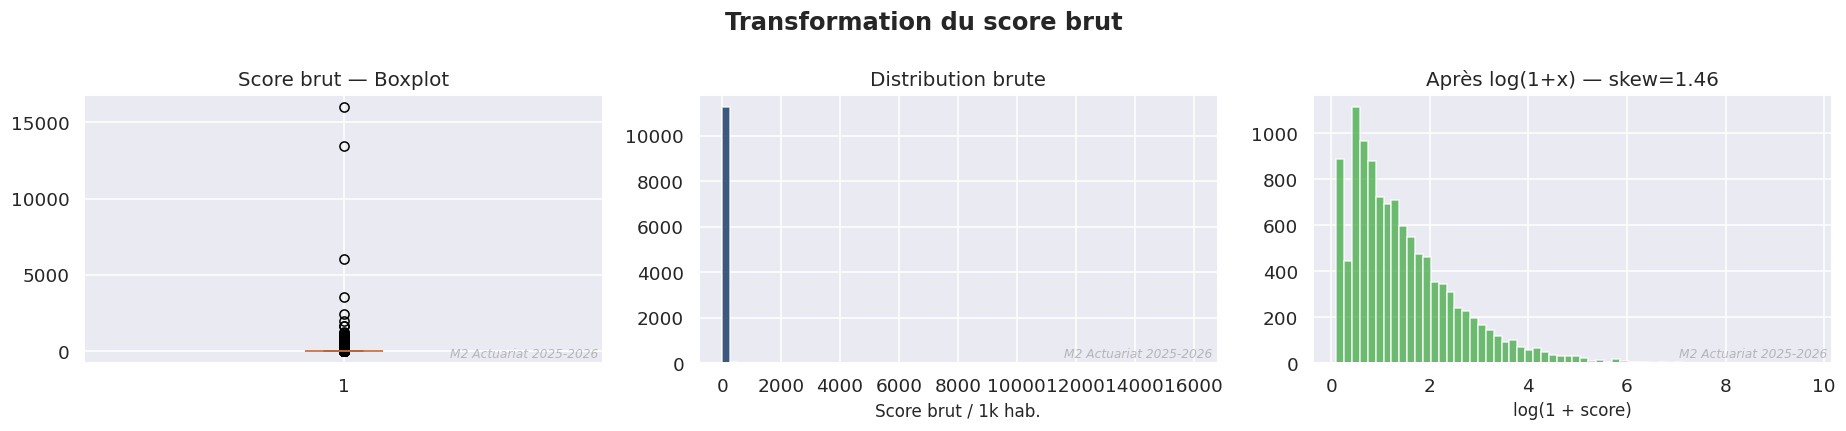

Skewness avant : 59.964
Skewness après : 1.458


In [ ]:
# ---------------------------------------------------------------------------
# Transformation log + visualisation de la distribution du score
# ---------------------------------------------------------------------------
score_raw = df_final['score_brut_per_1k'].replace([np.inf,-np.inf], np.nan).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Transformation du score brut", fontweight='bold')

axes[0].boxplot(score_raw, patch_artist=True,
                boxprops=dict(facecolor='#e94560', alpha=0.7))
axes[0].set_title("Score brut — Boxplot")
watermark(axes[0])

axes[1].hist(score_raw, bins=60, color='#0f3460', edgecolor='white', alpha=0.8)
axes[1].set_title("Distribution brute")
axes[1].set_xlabel("Score brut / 1k hab.")
watermark(axes[1])

score_log = np.log1p(score_raw)
axes[2].hist(score_log, bins=60, color='#4caf50', edgecolor='white', alpha=0.8)
axes[2].set_title(f"Après log(1+x) — skew={score_log.skew():.2f}")
axes[2].set_xlabel("log(1 + score)")
watermark(axes[2])

plt.tight_layout()
plt.show()

df_final['score_log'] = score_log
print(f"Skewness avant : {score_raw.skew():.3f}")
print(f"Skewness après : {score_log.skew():.3f}")

In [ ]:
# ---------------------------------------------------------------------------
# Split train/test + Normalisation min-max (SANS data leakage)
# ---------------------------------------------------------------------------
feature_cols = [
    'nb_accidents', 'prop_nuit', 'prop_autoroute', 'prop_hiver',
    'prop_agglo', 'prop_meteo_anormale', 'prop_weekend', 'prop_multi_vehicule',
    'population', 'nb_menages', 'superficie_km2', 'salaire_net_horaire_moyen',
    'part_pop_15_29', 'part_pop_60plus', 'densite_pop', 'taux_chomage',
    'part_cadres', 'is_transit', 'nb_vehicules_moy', 'nb_2roues_moy',
]
feature_cols = [c for c in feature_cols if c in df_final.columns]

X = df_final[feature_cols].fillna(0)
y = df_final['score_log'].fillna(0)

# Split AVANT toute normalisation
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Features : {len(feature_cols)}")
print(f"Train    : {X_train_raw.shape[0]:,} communes")
print(f"Test     : {X_test_raw.shape[0]:,}  communes")
print("\nLa séparation train/test est indispensable pour évaluer la capacité de")
print("généralisation du modèle sur des données non vues. Sans elle, les métriques")
print("seraient biaisées (sur-apprentissage non détecté).")

# Normalisation min-max FITTÉE SUR LE TRAIN UNIQUEMENT
scaler_mm = MinMaxScaler()
X_train_mm = pd.DataFrame(scaler_mm.fit_transform(X_train_raw),
                            columns=feature_cols, index=X_train_raw.index)
X_test_mm  = pd.DataFrame(scaler_mm.transform(X_test_raw),
                            columns=feature_cols, index=X_test_raw.index)

# Normalisation de y
y_min, y_max  = y_train_raw.min(), y_train_raw.max()
y_train_norm  = (y_train_raw - y_min) / (y_max - y_min)
y_test_norm   = (y_test_raw  - y_min) / (y_max - y_min)

# Standardisation (pour KNN, SVM, PCA)
scaler_std    = StandardScaler()
X_train_std   = scaler_std.fit_transform(X_train_raw)
X_test_std    = scaler_std.transform(X_test_raw)

# Variable binaire : 1 si score > moyenne du train
seuil_bin     = y_train_norm.mean()
y_train_bin   = (y_train_norm > seuil_bin).astype(int)
y_test_bin    = (y_test_norm  > seuil_bin).astype(int)

df_final['score_norm'] = ((y - y_min) / (y_max - y_min)).clip(0, 1)
df_final['score_bin']  = (df_final['score_norm'] > seuil_bin).astype(int)

print(f"\nSeuil score_bin (moyenne train) : {seuil_bin:.4f}")
print(f"Part haut-risque train          : {y_train_bin.mean():.2%}")
print(f"Part haut-risque test           : {y_test_bin.mean():.2%}")

Features : 20
Train    : 9,048 communes
Test     : 2,263  communes

La séparation train/test est indispensable pour évaluer la capacité de
généralisation du modèle sur des données non vues. Sans elle, les métriques
seraient biaisées (sur-apprentissage non détecté).

Seuil score_bin (moyenne train) : 0.1430
Part haut-risque train          : 40.08%
Part haut-risque test           : 40.87%


---
<a id='etape8'></a>
<div style="background:linear-gradient(90deg,#0f3460,#533483);padding:16px 26px;border-radius:10px;">
<h2 style="color:#fff;margin:0;">PARTIE 2 — Méthodes factorielles & linéaires</h2>
<p style="color:#ccccff;margin:4px 0 0 0;font-size:0.9em;">Matière : Analyse de Données II</p>
</div>

### Étape 8 — Corrélations & Multicolinéarité

La **multicolinéarité** pose problème pour la régression linéaire car :
- Les estimateurs OLS ont une variance élevée (instabilité des β)
- La matrice XᵀX est mal conditionnée → amplification du bruit
- Les coefficients perdent leur interprétabilité individuelle

**Solution :** ACP pour décorréler les features avant régression.

               var1             var2     r
prop_multi_vehicule nb_vehicules_moy 0.885
     prop_autoroute       is_transit 0.517


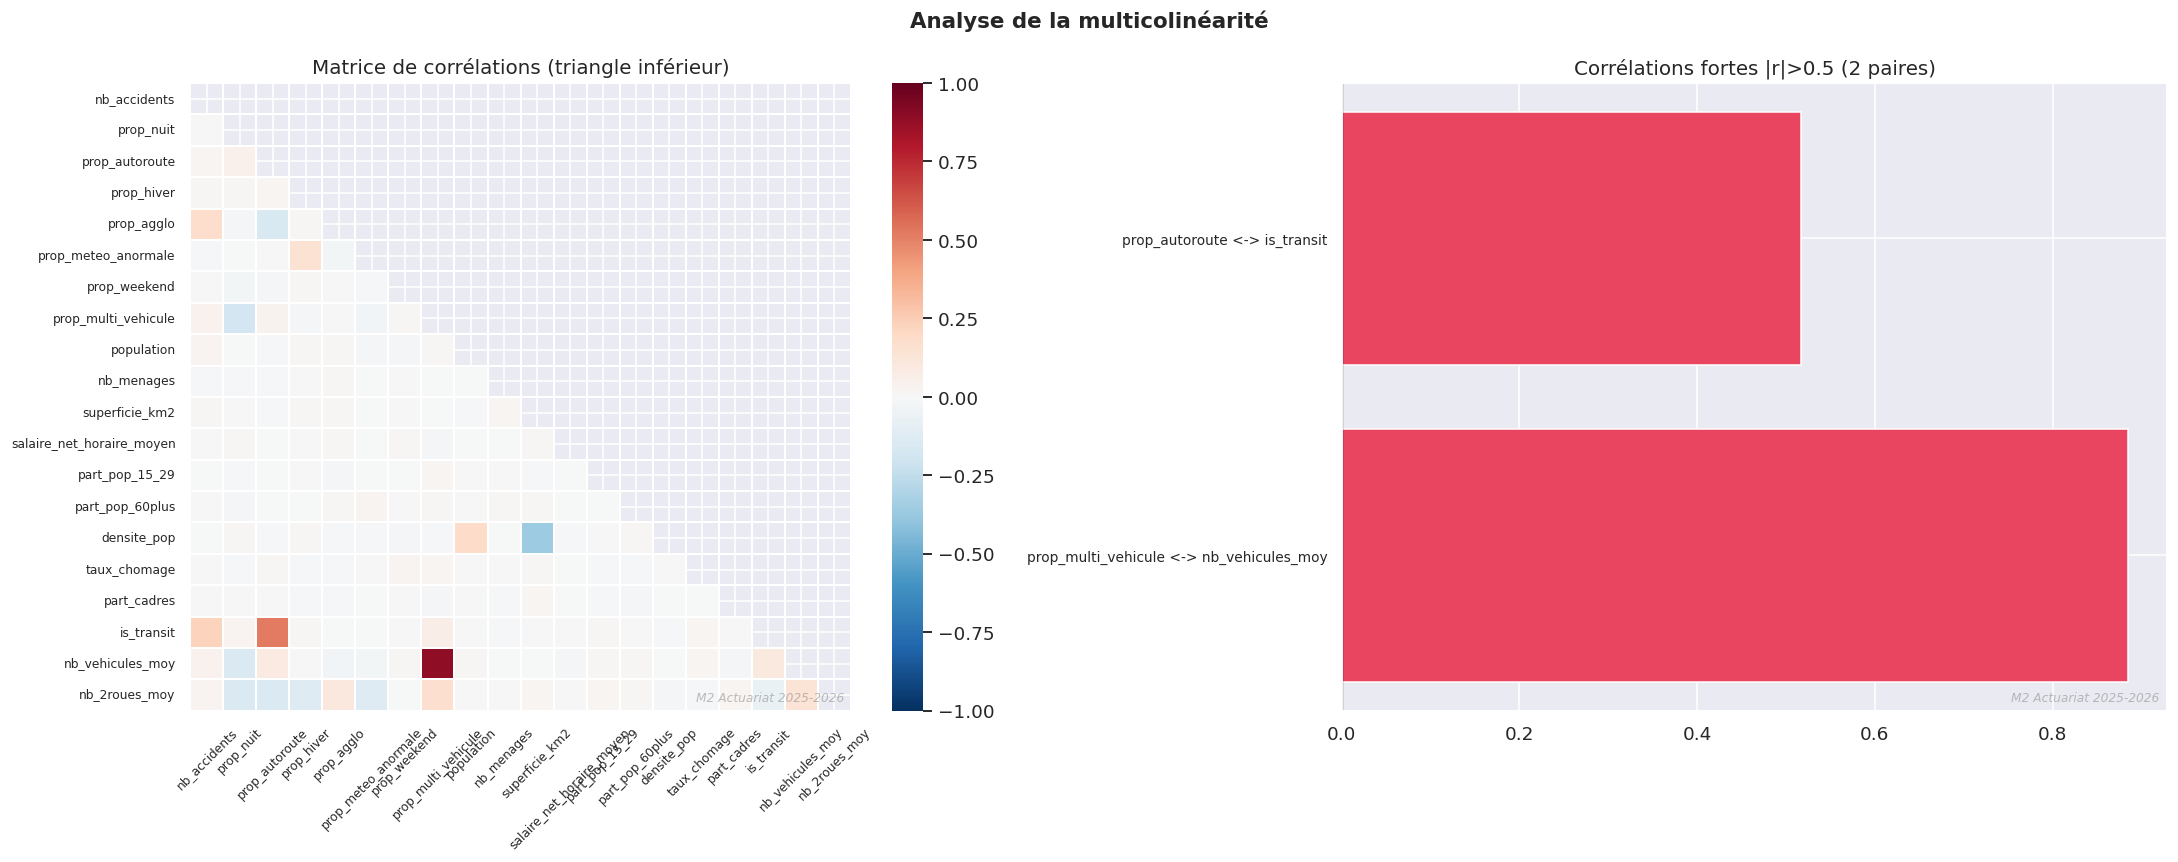

In [ ]:
corr_matrix = X_train_raw.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Analyse de la multicolinéarité", fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], annot=False, cmap='RdBu_r', mask=mask,
            vmin=-1, vmax=1, linewidths=0.3)
axes[0].set_title("Matrice de corrélations (triangle inférieur)")
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)
watermark(axes[0])

strong = [
    {'var1': corr_matrix.columns[i], 'var2': corr_matrix.columns[j],
     'r': round(corr_matrix.iloc[i,j], 3)}
    for i in range(len(corr_matrix.columns))
    for j in range(i+1, len(corr_matrix.columns))
    if abs(corr_matrix.iloc[i,j]) > 0.5
]
df_strong = pd.DataFrame(strong).sort_values('r', ascending=False)

if not df_strong.empty:
    colors_s = ['#e94560' if r > 0 else '#0f3460' for r in df_strong['r']]
    axes[1].barh(range(len(df_strong)), df_strong['r'], color=colors_s, edgecolor='white')
    axes[1].set_yticks(range(len(df_strong)))
    axes[1].set_yticklabels(
        [f"{row.var1} <-> {row.var2}" for row in df_strong.itertuples()], fontsize=9
    )
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title(f"Corrélations fortes |r|>0.5 ({len(df_strong)} paires)")
    watermark(axes[1])
    print(df_strong.to_string(index=False))
else:
    axes[1].text(0.5, 0.5, "Aucune corrélation forte (|r|>0.5)",
                 ha='center', va='center', transform=axes[1].transAxes)
    print("Aucune corrélation forte détectée.")

plt.tight_layout()
plt.show()

### ACP — Analyse en Composantes Principales

**Utilité :**
- Réduit la dimensionnalité (moins de features, même information)
- Produit des composantes orthogonales → résout la multicolinéarité
- Permet la visualisation de la structure des données

> **Anti data leakage :** `pca.fit()` uniquement sur le train, `transform()` sur train ET test.

Composantes pour 80% de variance : 14
Composantes pour 95% de variance : 18


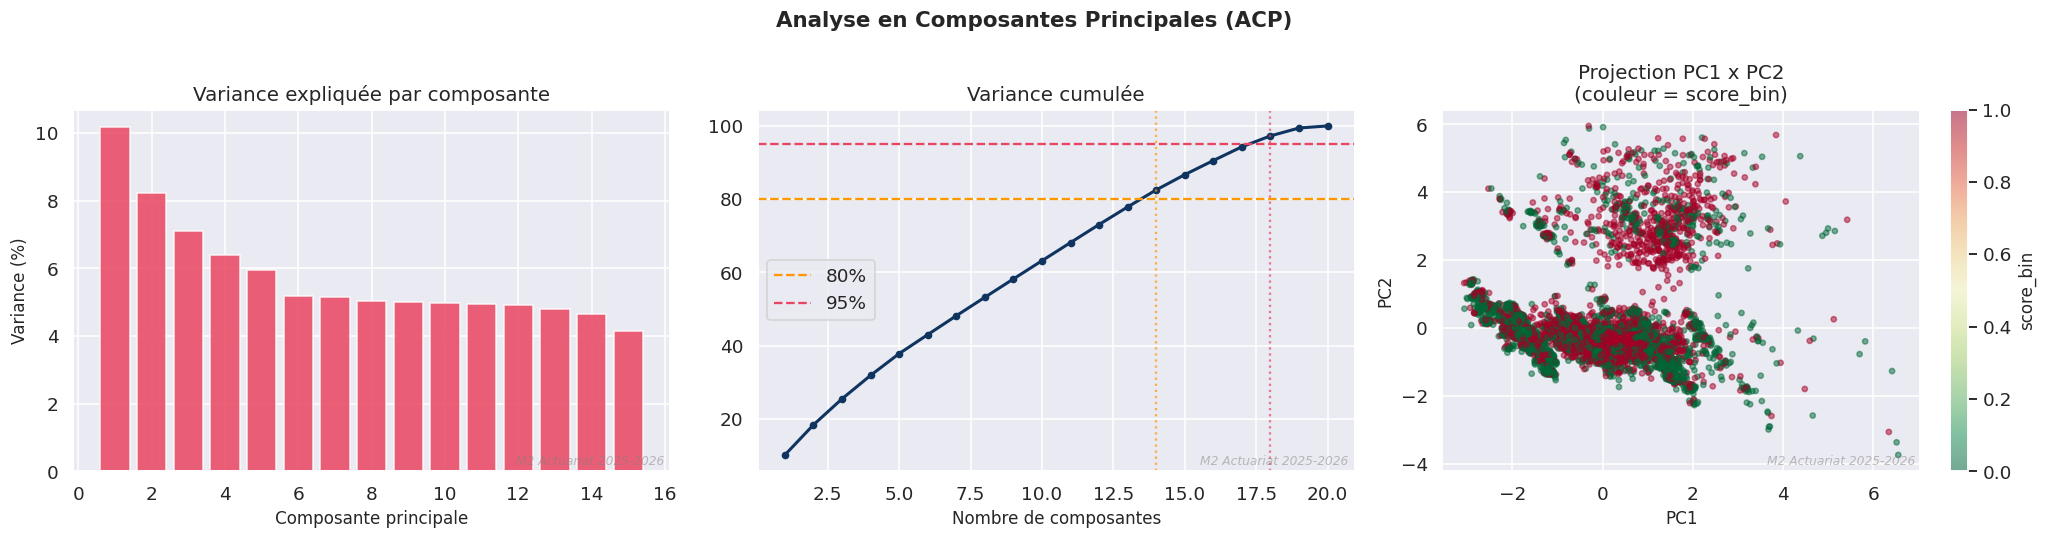


Contributions des features aux 3 premières composantes (top 8 sur PC1) :
                          PC1       PC2       PC3
prop_multi_vehicule  0.649948 -0.061906  0.032286
nb_vehicules_moy     0.647763 -0.010644  0.037728
prop_nuit           -0.230512  0.185424  0.016971
nb_2roues_moy        0.215325 -0.341379 -0.051656
is_transit           0.158961  0.598813 -0.040230
prop_autoroute       0.109355  0.628774 -0.004857
nb_accidents         0.099281  0.159116 -0.053534
prop_meteo_anormale -0.072155  0.108061 -0.000279


In [ ]:
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_std)
X_train_pca = pca.transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)

cumvar    = np.cumsum(pca.explained_variance_ratio_)
n_comp80  = int(np.argmax(cumvar >= 0.80) + 1)
n_comp95  = int(np.argmax(cumvar >= 0.95) + 1)

print(f"Composantes pour 80% de variance : {n_comp80}")
print(f"Composantes pour 95% de variance : {n_comp95}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("Analyse en Composantes Principales (ACP)", fontsize=14, fontweight='bold')

n_show = min(15, len(pca.explained_variance_ratio_))
axes[0].bar(range(1, n_show+1), pca.explained_variance_ratio_[:n_show]*100,
            color='#e94560', edgecolor='white', alpha=0.85)
axes[0].set_title("Variance expliquée par composante")
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance (%)")
watermark(axes[0])

axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color='#0f3460', linewidth=2, markersize=4)
axes[1].axhline(80, color='#ff9800', linestyle='--', label='80%')
axes[1].axhline(95, color='#e94560', linestyle='--', label='95%')
axes[1].axvline(n_comp80, color='#ff9800', linestyle=':', alpha=0.7)
axes[1].axvline(n_comp95, color='#e94560', linestyle=':', alpha=0.7)
axes[1].set_title("Variance cumulée")
axes[1].set_xlabel("Nombre de composantes")
axes[1].legend()
watermark(axes[1])

sc = axes[2].scatter(X_train_pca[:,0], X_train_pca[:,1],
                     c=y_train_bin.values, cmap='RdYlGn_r', alpha=0.5, s=12)
plt.colorbar(sc, ax=axes[2], label='score_bin')
axes[2].set_title("Projection PC1 x PC2\n(couleur = score_bin)")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
watermark(axes[2])

plt.tight_layout()
plt.show()

X_train_pca80 = X_train_pca[:, :n_comp80]
X_test_pca80  = X_test_pca[:,  :n_comp80]

loadings = pd.DataFrame(pca.components_[:3].T, index=feature_cols, columns=['PC1','PC2','PC3'])
print("\nContributions des features aux 3 premières composantes (top 8 sur PC1) :")
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(8).to_string())

<a id='etape9'></a>
### Étape 9 — Régression linéaire (prédire `score_norm`) & Logistique (prédire `score_bin`)

RÉGRESSION LINÉAIRE — Résultats
                          Modèle  R² train  R² test  RMSE train  RMSE test  MAE test
Régr. Linéaire (features brutes)    0.4648   0.5045      0.0855     0.0824    0.0643
   Régr. Linéaire (ACP 14 comp.)    0.4030   0.4504      0.0903     0.0868    0.0679


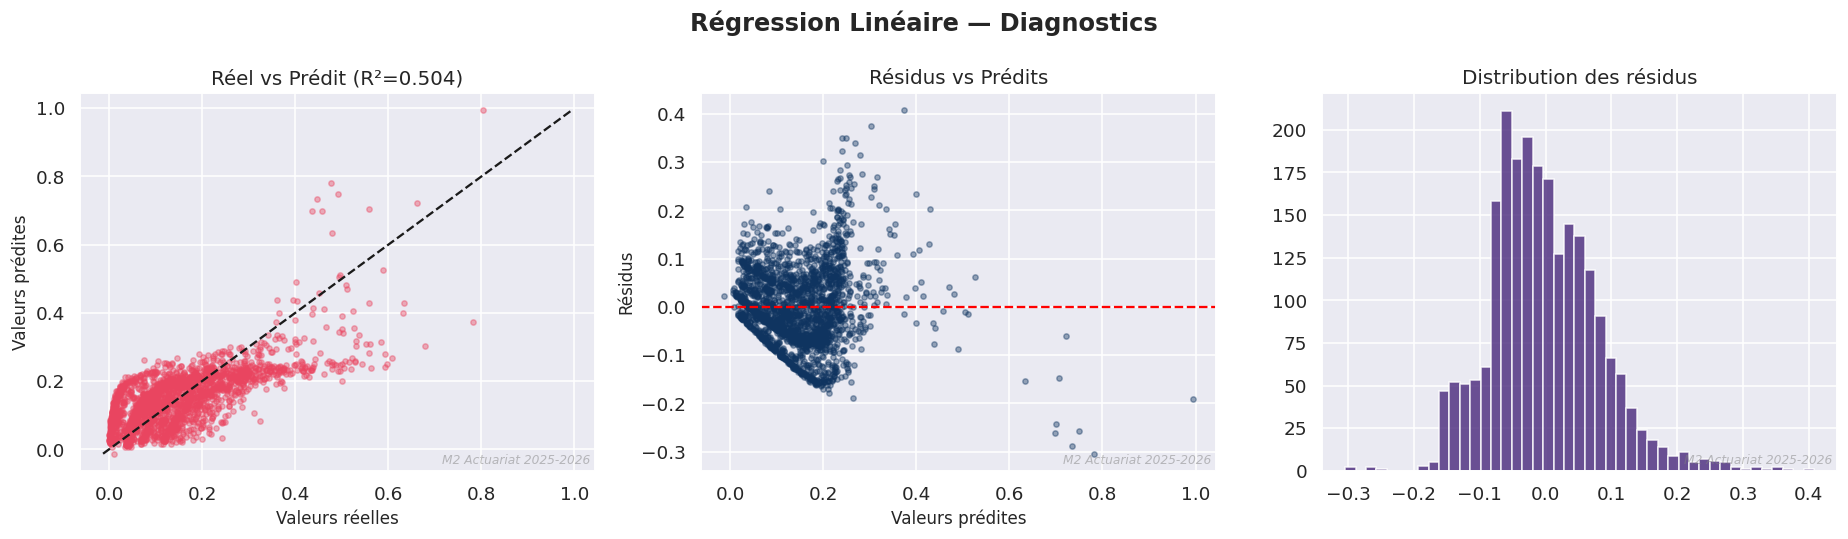


Top 8 coefficients (|coef|) :
            feature      coef
       nb_accidents  1.031789
         population -0.225008
         is_transit  0.081111
   nb_vehicules_moy  0.080915
     prop_autoroute -0.037554
      nb_2roues_moy -0.024690
          prop_nuit  0.016224
prop_multi_vehicule -0.014870


In [ ]:
def eval_reg(model, Xtr, Xte, ytr, yte, nom):
    model.fit(Xtr, ytr)
    yp_tr = model.predict(Xtr)
    yp_te = model.predict(Xte)
    return {
        'Modèle':     nom,
        'R² train':   round(r2_score(ytr, yp_tr), 4),
        'R² test':    round(r2_score(yte, yp_te), 4),
        'RMSE train': round(np.sqrt(mean_squared_error(ytr, yp_tr)), 4),
        'RMSE test':  round(np.sqrt(mean_squared_error(yte, yp_te)), 4),
        'MAE test':   round(mean_absolute_error(yte, yp_te), 4),
    }, model.predict(Xte)

reg_results = []
lr_brut = LinearRegression()
m1, yp_lr = eval_reg(lr_brut, X_train_mm, X_test_mm,
                      y_train_norm, y_test_norm, "Régr. Linéaire (features brutes)")
reg_results.append(m1)

lr_pca = LinearRegression()
m2, yp_lr_pca = eval_reg(lr_pca, X_train_pca80, X_test_pca80,
                           y_train_norm, y_test_norm,
                           f"Régr. Linéaire (ACP {n_comp80} comp.)")
reg_results.append(m2)

print("RÉGRESSION LINÉAIRE — Résultats")
print("=" * 68)
print(pd.DataFrame(reg_results).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Régression Linéaire — Diagnostics", fontweight='bold')

axes[0].scatter(y_test_norm, yp_lr, alpha=0.4, s=12, color='#e94560')
lims = [min(y_test_norm.min(), yp_lr.min()), max(y_test_norm.max(), yp_lr.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.5)
axes[0].set_title(f"Réel vs Prédit (R²={m1['R² test']:.3f})")
axes[0].set_xlabel("Valeurs réelles")
axes[0].set_ylabel("Valeurs prédites")
watermark(axes[0])

residus = y_test_norm.values - yp_lr
axes[1].scatter(yp_lr, residus, alpha=0.4, s=12, color='#0f3460')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title("Résidus vs Prédits")
axes[1].set_xlabel("Valeurs prédites")
axes[1].set_ylabel("Résidus")
watermark(axes[1])

axes[2].hist(residus, bins=45, color='#533483', edgecolor='white', alpha=0.85)
axes[2].set_title("Distribution des résidus")
watermark(axes[2])

plt.tight_layout()
plt.show()

coef_df = pd.DataFrame({'feature': feature_cols, 'coef': lr_brut.coef_})
print("\nTop 8 coefficients (|coef|) :")
print(coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(8).to_string(index=False))

RÉGRESSION LOGISTIQUE — Résultats
                            Modèle  Accuracy  Precision  Recall     F1    AUC
Régr. Logistique (features brutes)    0.7693     0.7368  0.6778 0.7061 0.8256
   Régr. Logistique (ACP 14 comp.)    0.7565     0.7280  0.6454 0.6842 0.8124


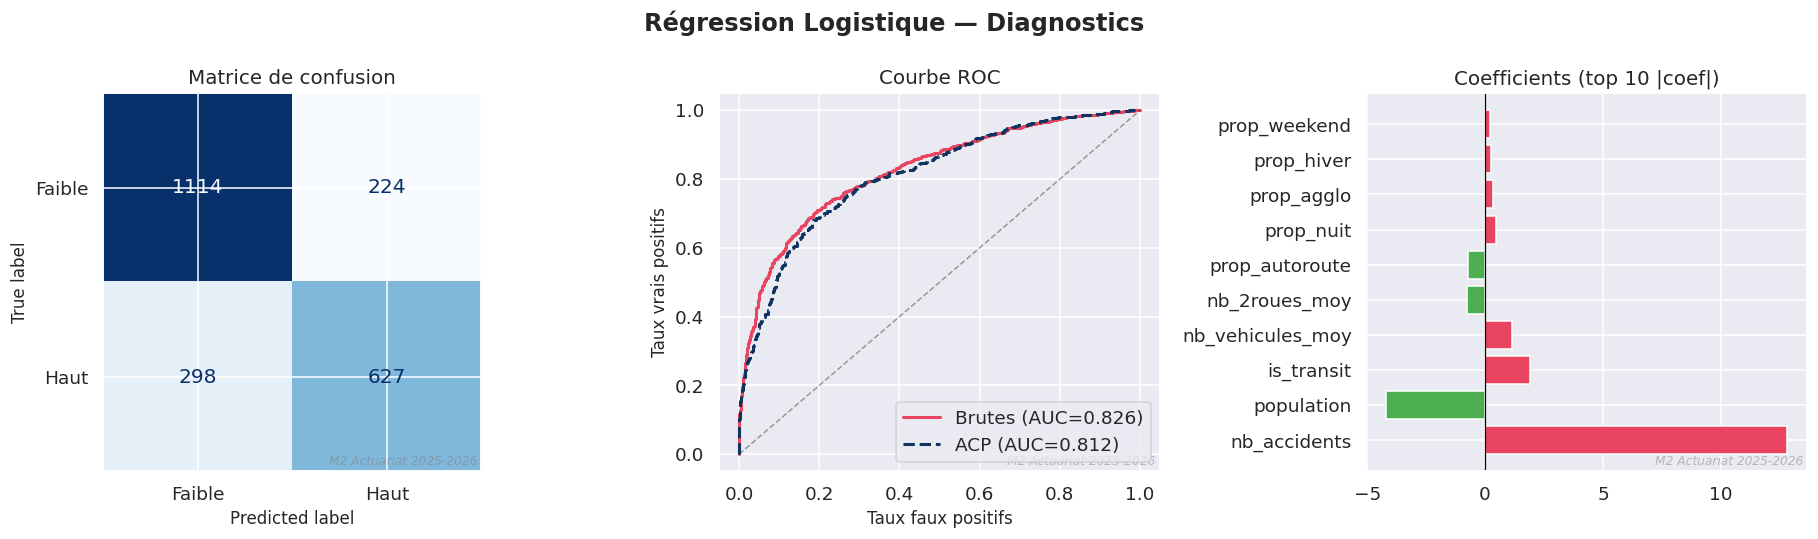

In [ ]:
def eval_clf(model, Xtr, Xte, ytr, yte, nom):
    model.fit(Xtr, ytr)
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:,1] if hasattr(model,'predict_proba') else None
    return {
        'Modèle':    nom,
        'Accuracy':  round(accuracy_score(yte, yp), 4),
        'Precision': round(precision_score(yte, yp, zero_division=0), 4),
        'Recall':    round(recall_score(yte, yp, zero_division=0), 4),
        'F1':        round(f1_score(yte, yp, zero_division=0), 4),
        'AUC':       round(roc_auc_score(yte, ypr), 4) if ypr is not None else 0,
    }, yp, ypr

clf_results = []
logr_brut = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
m_l1, yp_l1, ypr_l1 = eval_clf(logr_brut, X_train_mm, X_test_mm,
                                 y_train_bin, y_test_bin, "Régr. Logistique (features brutes)")
clf_results.append(m_l1)

logr_pca = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
m_l2, yp_l2, ypr_l2 = eval_clf(logr_pca, X_train_pca80, X_test_pca80,
                                 y_train_bin, y_test_bin,
                                 f"Régr. Logistique (ACP {n_comp80} comp.)")
clf_results.append(m_l2)

print("RÉGRESSION LOGISTIQUE — Résultats")
print("=" * 68)
print(pd.DataFrame(clf_results).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Régression Logistique — Diagnostics", fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test_bin, yp_l1),
    display_labels=['Faible','Haut']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Matrice de confusion")
watermark(axes[0])

fpr, tpr, _   = roc_curve(y_test_bin, ypr_l1)
fpr2, tpr2, _ = roc_curve(y_test_bin, ypr_l2)
axes[1].plot(fpr,  tpr,  color='#e94560', linewidth=2,
             label=f"Brutes (AUC={m_l1['AUC']:.3f})")
axes[1].plot(fpr2, tpr2, color='#0f3460', linewidth=2, linestyle='--',
             label=f"ACP (AUC={m_l2['AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4)
axes[1].set_title("Courbe ROC")
axes[1].set_xlabel("Taux faux positifs")
axes[1].set_ylabel("Taux vrais positifs")
axes[1].legend()
watermark(axes[1])

coef_log = pd.DataFrame({'feature': feature_cols, 'coef': logr_brut.coef_[0]})
coef_log = coef_log.reindex(coef_log['coef'].abs().sort_values(ascending=False).index).head(10)
axes[2].barh(coef_log['feature'], coef_log['coef'],
             color=['#e94560' if c>0 else '#4caf50' for c in coef_log['coef']],
             edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Coefficients (top 10 |coef|)")
watermark(axes[2])

plt.tight_layout()
plt.show()

---
<a id='etape10'></a>
<div style="background:linear-gradient(90deg,#1b4332,#2d6a4f);padding:16px 26px;border-radius:10px;">
<h2 style="color:#fff;margin:0;">PARTIE 3 — Machine Learning & Optimisation Stochastique</h2>
<p style="color:#ccffdd;margin:4px 0 0 0;font-size:0.9em;">Matière : ML / Optimisation Stochastique</p>
</div>

### Étape 10 — Optimisation Stochastique

#### 10.1 Descente de gradient classique (Batch GD) — implémentation manuelle

À chaque itération, le gradient est calculé sur **l'ensemble** du jeu d'entraînement :

```
∇L(w) = (1/n) · Xᵀ(Xw − y)
w ← w − α · ∇L(w)
```

In [ ]:
class BatchGradientDescent:
    def __init__(self, lr=0.05, n_iter=2000, tol=1e-7):
        self.lr, self.n_iter, self.tol = lr, n_iter, tol
        self.losses, self.w, self.b = [], None, None

    def fit(self, X, y):
        X, y  = np.array(X, dtype=float), np.array(y, dtype=float)
        n, p  = X.shape
        self.w, self.b = np.zeros(p), 0.0
        self.losses    = []
        for i in range(self.n_iter):
            res          = X @ self.w + self.b - y
            self.losses.append((res**2).mean() / 2)
            self.w      -= self.lr * (X.T @ res) / n
            self.b      -= self.lr * res.mean()
            if i > 0 and abs(self.losses[-2] - self.losses[-1]) < self.tol:
                print(f"  Convergence à l'itération {i+1}")
                break
        return self

    def predict(self, X):
        return np.array(X, dtype=float) @ self.w + self.b

bgd     = BatchGradientDescent(lr=0.05, n_iter=2000)
bgd.fit(X_train_mm.values, y_train_norm.values)
yp_bgd  = bgd.predict(X_test_mm.values)
r2_bgd  = r2_score(y_test_norm, yp_bgd)
rmse_bgd= np.sqrt(mean_squared_error(y_test_norm, yp_bgd))
print(f"Batch GD — R²={r2_bgd:.4f} | RMSE={rmse_bgd:.4f} | Itérations={len(bgd.losses)}")

  Convergence à l'itération 1726
Batch GD — R²=0.4152 | RMSE=0.0895 | Itérations=1726


#### 10.2 SGD manuel — mise à jour sur un exemple aléatoire à chaque itération

```
Pour chaque exemple (xᵢ, yᵢ) tiré aléatoirement :
    w ← w − α · (xᵢᵀw − yᵢ) · xᵢ
```
Plus rapide sur les grands datasets, convergence bruitée mais peut échapper aux minima locaux.

In [ ]:
class SGDManuel:
    def __init__(self, lr=0.05, n_epochs=200, tol=1e-7):
        self.lr, self.n_epochs, self.tol = lr, n_epochs, tol
        self.losses, self.w, self.b = [], None, None

    def fit(self, X, y):
        X, y  = np.array(X, dtype=float), np.array(y, dtype=float)
        n, p  = X.shape
        self.w, self.b = np.zeros(p), 0.0
        self.losses    = []
        lr             = self.lr
        rng            = np.random.default_rng(RANDOM_STATE)
        for epoch in range(self.n_epochs):
            epoch_loss = 0.0
            for i in rng.permutation(n):
                res        = X[i] @ self.w + self.b - y[i]
                self.w    -= lr * res * X[i]
                self.b    -= lr * res
                epoch_loss+= res**2
            self.losses.append(epoch_loss / (2*n))
            lr *= 0.995
            if epoch > 2 and abs(self.losses[-2] - self.losses[-1]) < self.tol:
                print(f"  Convergence à l'époque {epoch+1}")
                break
        return self

    def predict(self, X):
        return np.array(X, dtype=float) @ self.w + self.b

sgd_man  = SGDManuel(lr=0.05, n_epochs=200)
sgd_man.fit(X_train_mm.values, y_train_norm.values)
yp_sgd   = sgd_man.predict(X_test_mm.values)
r2_sgd   = r2_score(y_test_norm, yp_sgd)
rmse_sgd = np.sqrt(mean_squared_error(y_test_norm, yp_sgd))
print(f"SGD Manuel — R²={r2_sgd:.4f} | RMSE={rmse_sgd:.4f} | Époques={len(sgd_man.losses)}")

SGD Manuel — R²=0.5012 | RMSE=0.0826 | Époques=200


SGDRegressor sklearn — R²=0.4058 | RMSE=0.0902


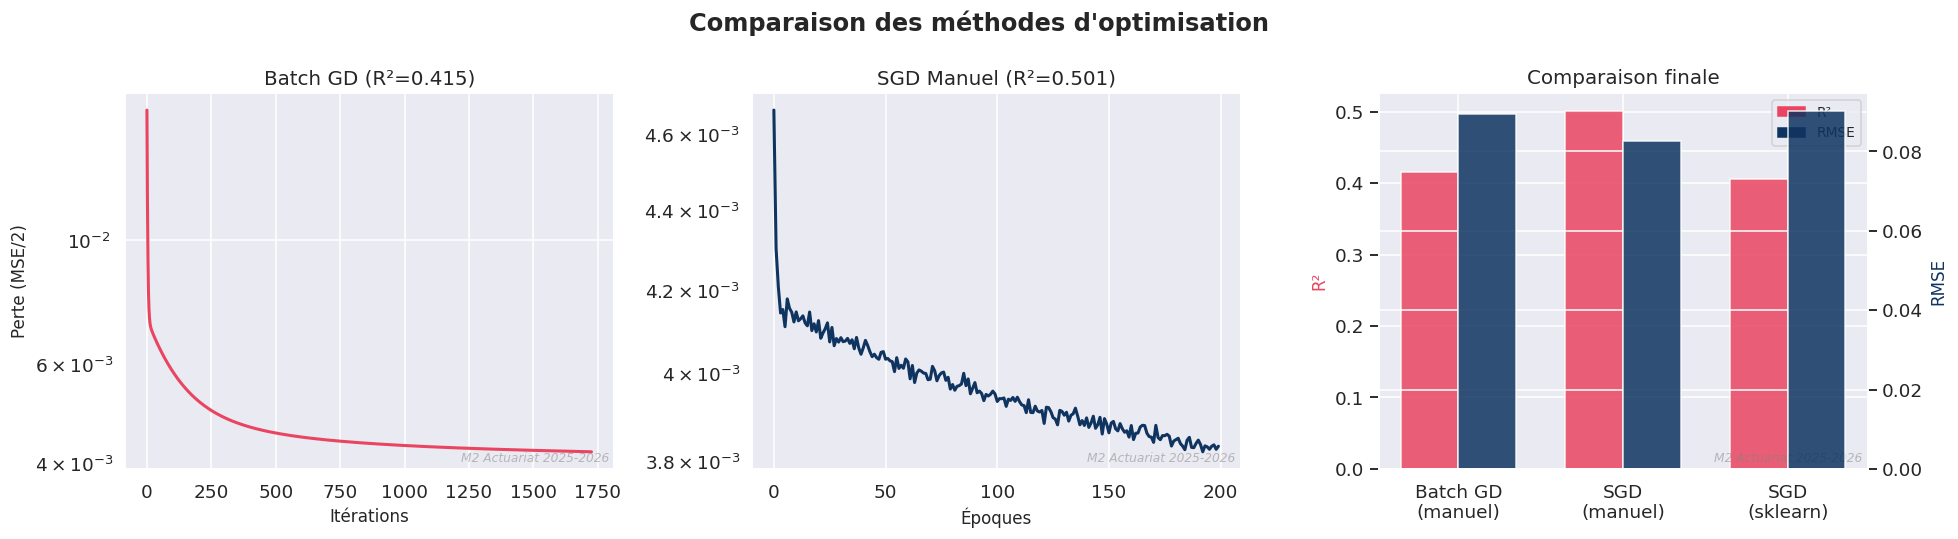


Batch GD  : gradient exact sur tout le dataset, convergence stable.
SGD manuel: mise à jour par exemple, rapide mais oscillant.
SGD sklearn: learning rate adaptatif + régularisation -> souvent plus performant.


In [ ]:
# SGDRegressor sklearn + comparaison visuelle
sgd_sk = SGDRegressor(loss='squared_error', max_iter=1000, tol=1e-4,
                      learning_rate='invscaling', eta0=0.01, random_state=RANDOM_STATE)
sgd_sk.fit(X_train_mm.values, y_train_norm.values)
yp_sgd_sk  = sgd_sk.predict(X_test_mm.values)
r2_sk      = r2_score(y_test_norm, yp_sgd_sk)
rmse_sk    = np.sqrt(mean_squared_error(y_test_norm, yp_sgd_sk))
print(f"SGDRegressor sklearn — R²={r2_sk:.4f} | RMSE={rmse_sk:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparaison des méthodes d'optimisation", fontweight='bold')

axes[0].plot(bgd.losses, color='#e94560', linewidth=2)
axes[0].set_title(f"Batch GD (R²={r2_bgd:.3f})")
axes[0].set_yscale('log')
axes[0].set_xlabel("Itérations")
axes[0].set_ylabel("Perte (MSE/2)")
watermark(axes[0])

axes[1].plot(sgd_man.losses, color='#0f3460', linewidth=2)
axes[1].set_title(f"SGD Manuel (R²={r2_sgd:.3f})")
axes[1].set_yscale('log')
axes[1].set_xlabel("Époques")
watermark(axes[1])

labels = ['Batch GD\n(manuel)', 'SGD\n(manuel)', 'SGD\n(sklearn)']
r2v    = [r2_bgd, r2_sgd, r2_sk]
rmse_v = [rmse_bgd, rmse_sgd, rmse_sk]
x      = np.arange(3)
w      = 0.35
axes[2].bar(x-w/2, r2v,    w, label='R²',   color='#e94560', alpha=0.85, edgecolor='white')
ax2t = axes[2].twinx()
ax2t.bar(x+w/2, rmse_v, w, label='RMSE', color='#0f3460', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel("R²", color='#e94560')
ax2t.set_ylabel("RMSE", color='#0f3460')
axes[2].set_title("Comparaison finale")
lns = [mpatches.Patch(color='#e94560', label='R²'),
       mpatches.Patch(color='#0f3460', label='RMSE')]
axes[2].legend(handles=lns, fontsize=9)
watermark(axes[2])

plt.tight_layout()
plt.show()

print("\nBatch GD  : gradient exact sur tout le dataset, convergence stable.")
print("SGD manuel: mise à jour par exemple, rapide mais oscillant.")
print("SGD sklearn: learning rate adaptatif + régularisation -> souvent plus performant.")

---
<a id='etape11'></a>
### Étape 11 — 7 Modèles de Classification (prédire `score_bin`)

| Modèle | Cas d'usage principal |
|--------|----------------------|
| KNN | Baseline, données bien séparées |
| SVM Linéaire | Haute dimension, séparation linéaire |
| SVM RBF | Frontières non-linéaires |
| Arbre de décision | Interprétabilité maximale |
| Random Forest | Robustesse, non-linéarités |
| Gradient Boosting | Performance maximale sur données tabulaires |
| Régression Logistique | Probabilités calibrées, interprétable |

In [ ]:
configs = [
    ("KNN (k=5)",         KNeighborsClassifier(n_neighbors=5),
                           X_train_std,       X_test_std),
    ("SVM Linéaire",      SVC(kernel='linear', probability=True, random_state=RANDOM_STATE),
                           X_train_std,       X_test_std),
    ("SVM RBF",           SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
                           X_train_std,       X_test_std),
    ("Arbre Décision",    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
                           X_train_mm.values, X_test_mm.values),
    ("Random Forest",     RandomForestClassifier(n_estimators=100, max_depth=8,
                                                  random_state=RANDOM_STATE),
                           X_train_mm.values, X_test_mm.values),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                      random_state=RANDOM_STATE),
                           X_train_mm.values, X_test_mm.values),
    ("Régr. Logistique",  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                           X_train_mm.values, X_test_mm.values),
]

all_results    = []
models_trained = {}
probs_dict     = {}

print(f"{'Modèle':<22}  {'Accuracy':>8}  {'F1':>8}  {'AUC':>8}")
print("-" * 55)
for nom, model, Xtr, Xte in configs:
    model.fit(Xtr, y_train_bin)
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:,1] if hasattr(model,'predict_proba') else None
    m = {
        'Modèle':    nom,
        'Accuracy':  round(accuracy_score(y_test_bin, yp), 4),
        'Precision': round(precision_score(y_test_bin, yp, zero_division=0), 4),
        'Recall':    round(recall_score(y_test_bin, yp, zero_division=0), 4),
        'F1':        round(f1_score(y_test_bin, yp, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_test_bin, ypr), 4) if ypr is not None else 0,
    }
    all_results.append(m)
    models_trained[nom] = (model, Xte)
    probs_dict[nom]     = ypr
    print(f"{nom:<22}  {m['Accuracy']:>8.4f}  {m['F1']:>8.4f}  {m['AUC']:>8.4f}")

df_res = pd.DataFrame(all_results).sort_values('AUC', ascending=False).reset_index(drop=True)
print("\nClassement final par AUC décroissante :")
print(df_res.to_string(index=False))

Modèle                  Accuracy        F1       AUC
-------------------------------------------------------
KNN (k=5)                 0.7517    0.6733    0.8043
SVM Linéaire              0.8210    0.7774    0.8948
SVM RBF                   0.8202    0.7641    0.8823
Arbre Décision            0.8392    0.7934    0.8953
Random Forest             0.8374    0.7880    0.8949
Gradient Boosting         0.8396    0.7927    0.9022
Régr. Logistique          0.7693    0.7061    0.8256

Classement final par AUC décroissante :
           Modèle  Accuracy  Precision  Recall     F1    AUC
Gradient Boosting    0.8396     0.8402  0.7503 0.7927 0.9022
   Arbre Décision    0.8392     0.8351  0.7557 0.7934 0.8953
    Random Forest    0.8374     0.8434  0.7395 0.7880 0.8949
     SVM Linéaire    0.8210     0.7908  0.7643 0.7774 0.8948
          SVM RBF    0.8202     0.8237  0.7124 0.7641 0.8823
 Régr. Logistique    0.7693     0.7368  0.6778 0.7061 0.8256
        KNN (k=5)    0.7517     0.7283  0.6259 0.673

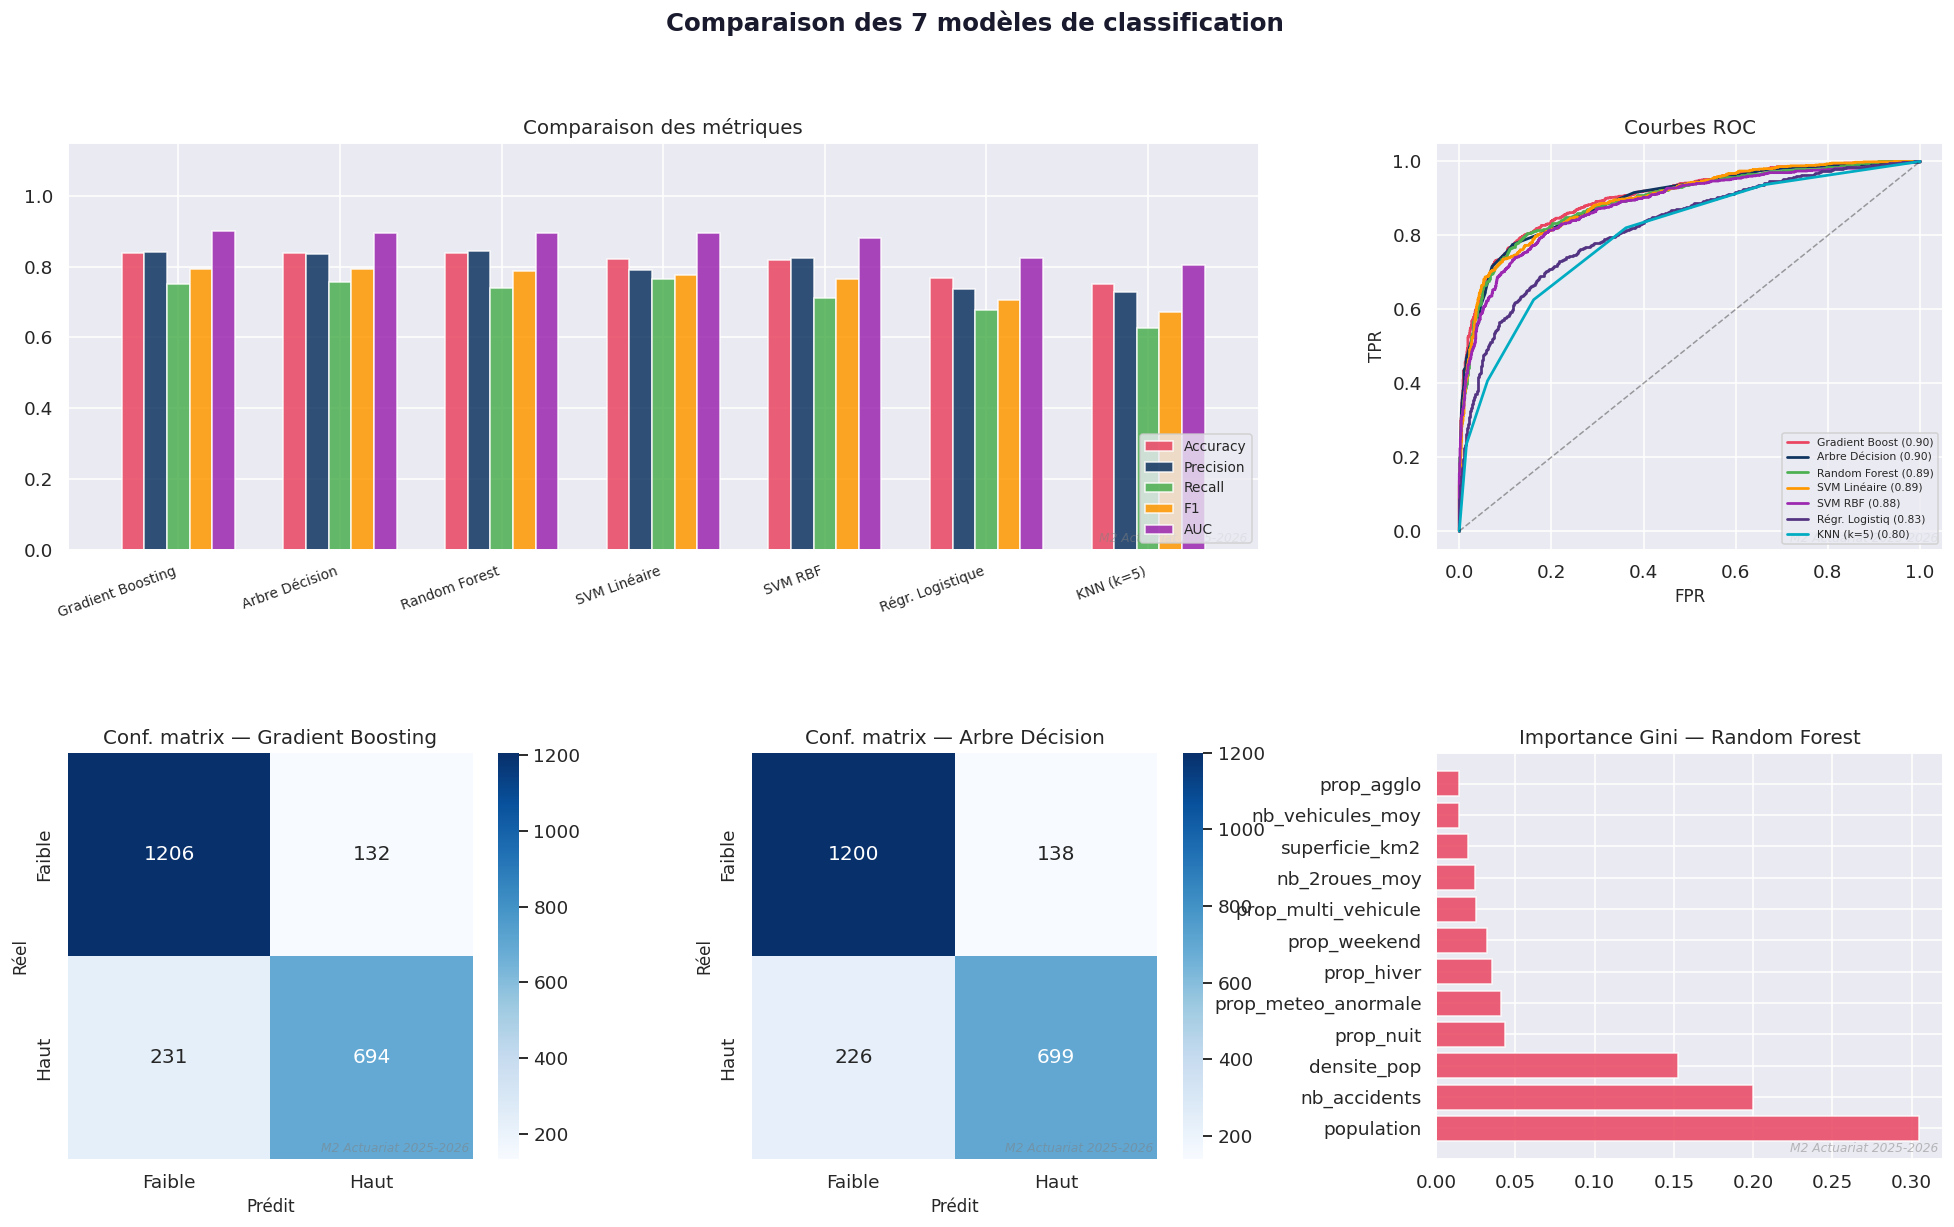

In [ ]:
palette = ['#e94560','#0f3460','#4caf50','#ff9800','#9c27b0','#533483','#00acc1']

fig = plt.figure(figsize=(22, 12))
fig.suptitle("Comparaison des 7 modèles de classification\n",
             fontsize=16, fontweight='bold', color='#1a1a2e')
gs = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# Barplot métriques
ax1 = fig.add_subplot(gs[0, :2])
metrics = ['Accuracy','Precision','Recall','F1','AUC']
pal     = ['#e94560','#0f3460','#4caf50','#ff9800','#9c27b0']
x = np.arange(len(df_res))
w = 0.14
for i, (met, col) in enumerate(zip(metrics, pal)):
    ax1.bar(x+i*w-2*w, df_res[met], w, label=met, color=col, alpha=0.85, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(df_res['Modèle'], rotation=20, ha='right', fontsize=9)
ax1.set_title("Comparaison des métriques")
ax1.legend(loc='lower right', fontsize=9)
ax1.set_ylim(0, 1.15)
watermark(ax1)

# Courbes ROC
ax2 = fig.add_subplot(gs[0, 2])
for idx, row in df_res.iterrows():
    nm = row['Modèle']
    if probs_dict.get(nm) is not None:
        fp, tp, _ = roc_curve(y_test_bin, probs_dict[nm])
        ax2.plot(fp, tp, linewidth=1.8,
                 label=f"{nm[:14]} ({row['AUC']:.2f})",
                 color=palette[idx % len(palette)])
ax2.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4)
ax2.set_title("Courbes ROC")
ax2.legend(fontsize=7, loc='lower right')
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
watermark(ax2)

# Matrices de confusion top 2
for i, nm in enumerate(df_res.head(2)['Modèle'].tolist()):
    ax = fig.add_subplot(gs[1, i])
    mo, Xte = models_trained[nm]
    cm = confusion_matrix(y_test_bin, mo.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Faible','Haut'], yticklabels=['Faible','Haut'])
    ax.set_title(f"Conf. matrix — {nm}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    watermark(ax)

# Importance features RF
ax5 = fig.add_subplot(gs[1, 2])
rf_m, _ = models_trained["Random Forest"]
fi = pd.DataFrame({'feature': feature_cols, 'imp': rf_m.feature_importances_})
fi = fi.sort_values('imp', ascending=False).head(12)
ax5.barh(fi['feature'], fi['imp'], color='#e94560', edgecolor='white', alpha=0.85)
ax5.set_title("Importance Gini — Random Forest")
watermark(ax5)

plt.tight_layout()
plt.show()

---
<a id='etape12'></a>
### Étape 12 — Hyperparamètres, Validation croisée, Explicabilité, RFE

In [ ]:
# RandomizedSearchCV sur Random Forest
param_dist = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}
print("Recherche d'hyperparamètres (RandomizedSearchCV, 30 iter., CV=5)...")
rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_dist, n_iter=30, cv=5, scoring='roc_auc',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rs.fit(X_train_mm.values, y_train_bin.values)
best_rf = rs.best_estimator_

print("\nMeilleurs hyperparamètres :")
for k, v in rs.best_params_.items():
    print(f"  {k:<25} = {v}")

yp_brf  = best_rf.predict(X_test_mm.values)
ypr_brf = best_rf.predict_proba(X_test_mm.values)[:,1]
print(f"\nRF optimisé — F1={f1_score(y_test_bin,yp_brf,zero_division=0):.4f}  "
      f"AUC={roc_auc_score(y_test_bin,ypr_brf):.4f}")

Recherche d'hyperparamètres (RandomizedSearchCV, 30 iter., CV=5)...

Meilleurs hyperparamètres :
  n_estimators              = 200
  min_samples_split         = 5
  min_samples_leaf          = 4
  max_features              = log2
  max_depth                 = 10

RF optimisé — F1=0.7926  AUC=0.8969


Modèle                      F1 moy    ± std   AUC moy    ± std
--------------------------------------------------------------
Régr. Logistique            0.6861   0.0145    0.8188   0.0131
RF optimisé                 0.7900   0.0084    0.9025   0.0028
Gradient Boosting           0.7926   0.0073    0.9052   0.0029


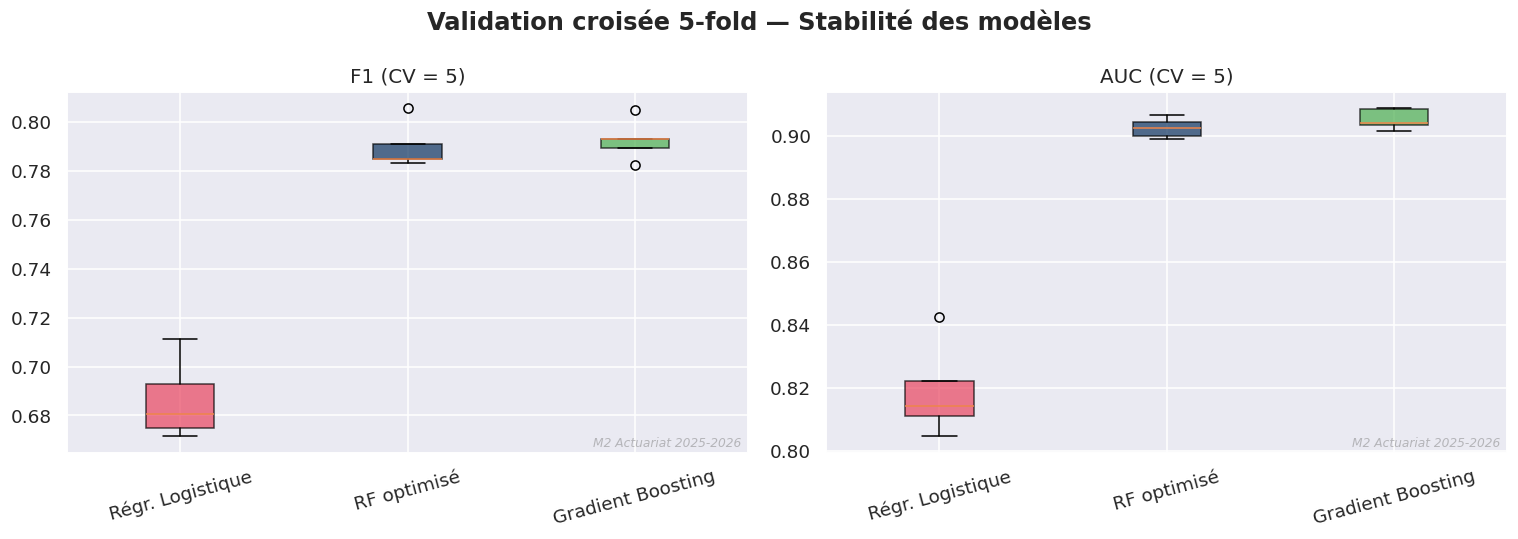

In [ ]:
# Validation croisée 5-fold
cv_mods = {
    "Régr. Logistique":  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RF optimisé":       RandomForestClassifier(**rs.best_params_, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}
print(f"{'Modèle':<24}  {'F1 moy':>8}  {'± std':>7}  {'AUC moy':>8}  {'± std':>7}")
print("-" * 62)
cv_res = {}
for nom, mo in cv_mods.items():
    sf1  = cross_val_score(mo, X_train_mm.values, y_train_bin.values, cv=5,
                            scoring='f1',       n_jobs=-1)
    sauc = cross_val_score(mo, X_train_mm.values, y_train_bin.values, cv=5,
                            scoring='roc_auc',  n_jobs=-1)
    cv_res[nom] = {'F1': sf1, 'AUC': sauc}
    print(f"{nom:<24}  {sf1.mean():>8.4f}  {sf1.std():>7.4f}  "
          f"{sauc.mean():>8.4f}  {sauc.std():>7.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Validation croisée 5-fold — Stabilité des modèles", fontweight='bold')
for ax, metric in zip(axes, ['F1','AUC']):
    data = [cv_res[n][metric] for n in cv_mods]
    bp   = ax.boxplot(data, patch_artist=True, labels=list(cv_mods.keys()))
    for patch, col in zip(bp['boxes'], ['#e94560','#0f3460','#4caf50']):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    ax.set_title(f"{metric} (CV = 5)")
    ax.tick_params(axis='x', rotation=15)
    watermark(ax)
plt.tight_layout()
plt.show()

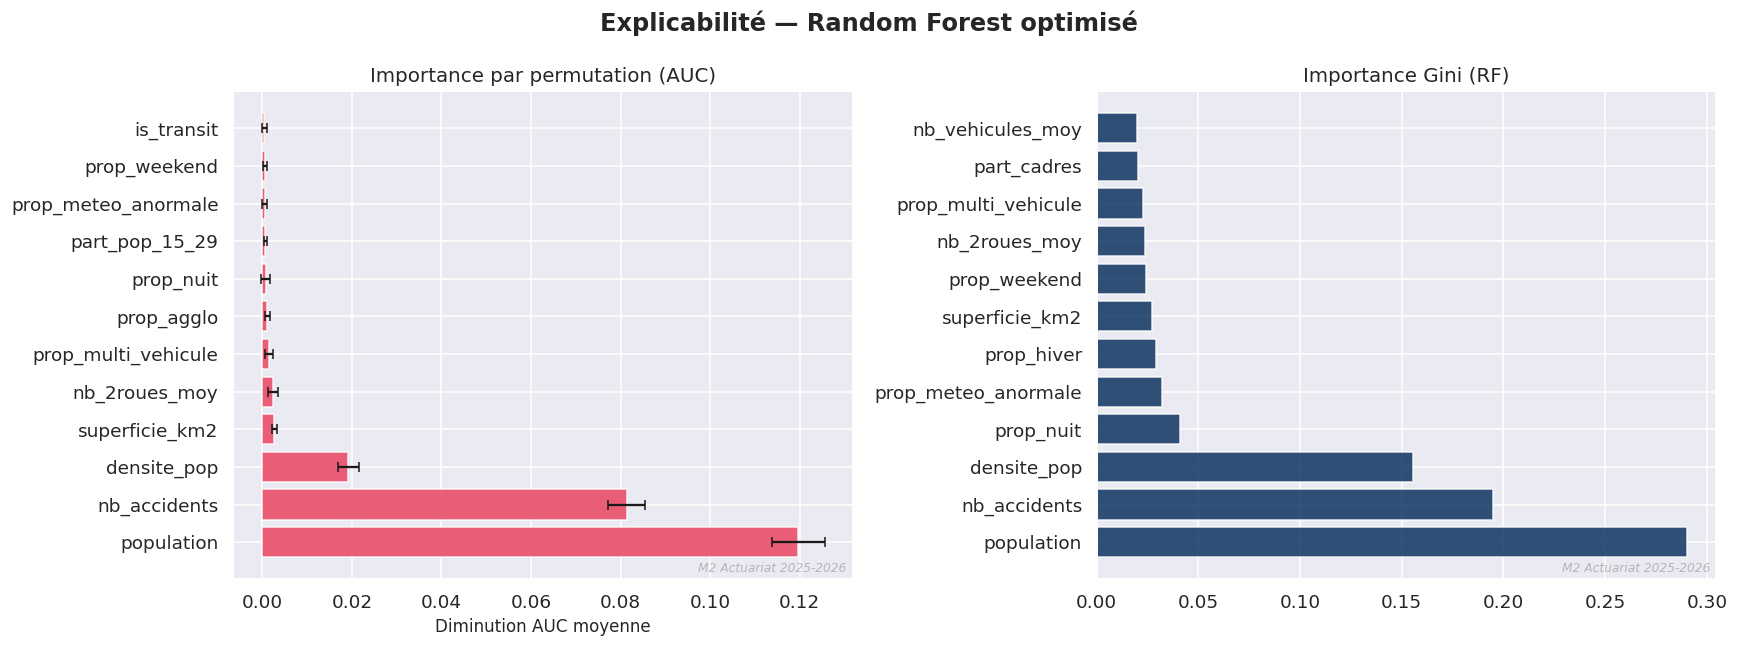

<Figure size 1100x660 with 0 Axes>

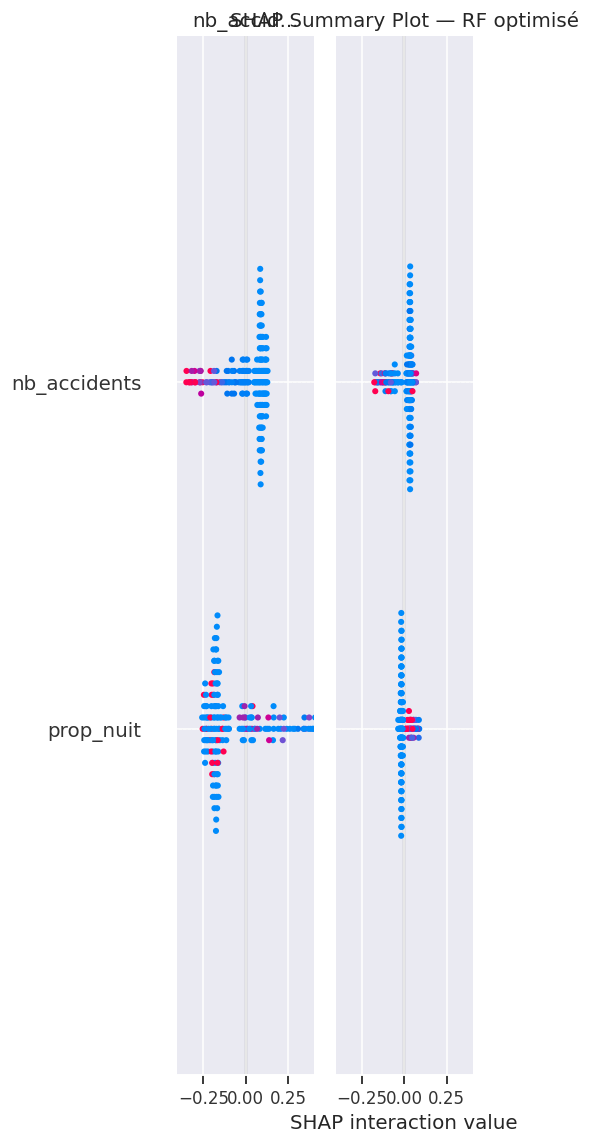


Pourquoi l'explicabilité est cruciale en assurance :
  - Réglementation DDA / Solvabilité II : décisions justifiables
  - Droit des assurés à contester un tarif
  - Détection de biais discriminatoires (âge, sexe) interdits par la loi
  - Audit actuariel exige la traçabilité des modèles


In [ ]:
# Explicabilité — permutation importance + SHAP
best_rf.fit(X_train_mm.values, y_train_bin.values)
pi = permutation_importance(best_rf, X_test_mm.values, y_test_bin.values,
                             n_repeats=15, random_state=RANDOM_STATE, scoring='roc_auc')
pi_df = pd.DataFrame({'feature': feature_cols,
                       'mean': pi.importances_mean, 'std': pi.importances_std}) \
          .sort_values('mean', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Explicabilité — Random Forest optimisé", fontweight='bold')

axes[0].barh(pi_df['feature'], pi_df['mean'], xerr=pi_df['std'],
             color='#e94560', edgecolor='white', alpha=0.85, capsize=3)
axes[0].set_title("Importance par permutation (AUC)")
axes[0].set_xlabel("Diminution AUC moyenne")
watermark(axes[0])

gi_df = pd.DataFrame({'feature': feature_cols, 'imp': best_rf.feature_importances_}) \
          .sort_values('imp', ascending=False).head(12)
axes[1].barh(gi_df['feature'], gi_df['imp'], color='#0f3460', edgecolor='white', alpha=0.85)
axes[1].set_title("Importance Gini (RF)")
watermark(axes[1])
plt.tight_layout()
plt.show()

if SHAP_AVAILABLE:
    try:
        explainer = shap.TreeExplainer(best_rf)
        sv = explainer.shap_values(X_test_mm.values[:200])
        sv_pos = sv[1] if isinstance(sv, list) else sv
        plt.figure(figsize=(10, 6))
        shap.summary_plot(sv_pos, X_test_mm.values[:200],
                          feature_names=feature_cols, show=False, max_display=12)
        plt.title("SHAP Summary Plot — RF optimisé")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"SHAP : {e}")

print("\nPourquoi l'explicabilité est cruciale en assurance :")
print("  - Réglementation DDA / Solvabilité II : décisions justifiables")
print("  - Droit des assurés à contester un tarif")
print("  - Détection de biais discriminatoires (âge, sexe) interdits par la loi")
print("  - Audit actuariel exige la traçabilité des modèles")

Nombre optimal de features : 11
AUC avec 11 features : 0.8169
AUC avec toutes (20) : 0.8161

Features sélectionnées : ['nb_accidents', 'prop_nuit', 'prop_autoroute', 'prop_hiver', 'prop_agglo', 'prop_weekend', 'population', 'densite_pop', 'is_transit', 'nb_vehicules_moy', 'nb_2roues_moy']


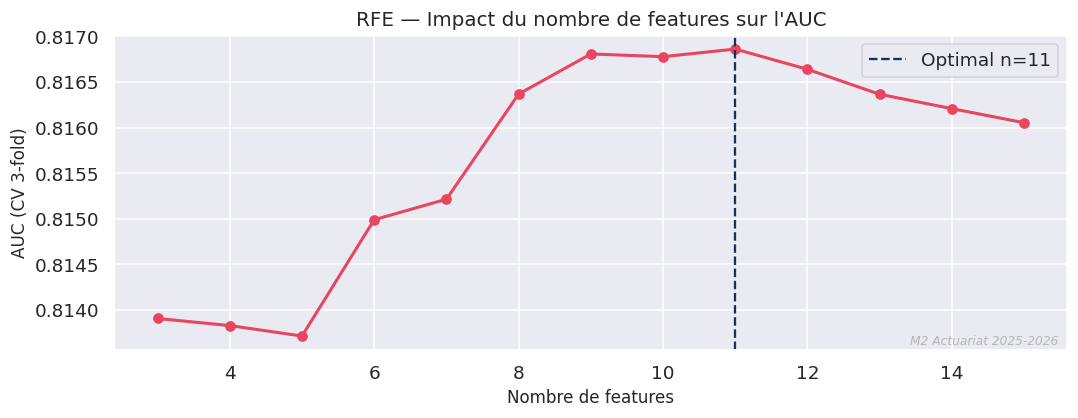

In [ ]:
# RFE — Recursive Feature Elimination
rfe_scores = []
for n in range(3, min(len(feature_cols)+1, 16)):
    rfe_n = RFE(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_features_to_select=n, step=1)
    sc = cross_val_score(rfe_n, X_train_mm.values, y_train_bin.values,
                          cv=3, scoring='roc_auc').mean()
    rfe_scores.append((n, sc))

rfe_df = pd.DataFrame(rfe_scores, columns=['n_feat','auc'])
best_n = int(rfe_df.loc[rfe_df['auc'].idxmax(), 'n_feat'])

rfe_final = RFE(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_features_to_select=best_n, step=1)
rfe_final.fit(X_train_mm.values, y_train_bin.values)
sel_feat = [f for f, s in zip(feature_cols, rfe_final.support_) if s]

print(f"Nombre optimal de features : {best_n}")
print(f"AUC avec {best_n} features : {rfe_df[rfe_df.n_feat==best_n]['auc'].values[0]:.4f}")
print(f"AUC avec toutes ({len(feature_cols)}) : {rfe_df.iloc[-1]['auc']:.4f}")
print(f"\nFeatures sélectionnées : {sel_feat}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rfe_df['n_feat'], rfe_df['auc'], 'o-', color='#e94560', linewidth=2, markersize=6)
ax.axvline(best_n, color='#0f3460', linestyle='--', linewidth=1.5, label=f'Optimal n={best_n}')
ax.set_xlabel("Nombre de features")
ax.set_ylabel("AUC (CV 3-fold)")
ax.set_title("RFE — Impact du nombre de features sur l'AUC")
ax.legend()
watermark(ax)
plt.tight_layout()
plt.show()

---
<a id='etape13'></a>
<div style="background:linear-gradient(90deg,#7b2d00,#c45000);padding:16px 26px;border-radius:10px;">
<h2 style="color:#fff;margin:0;">PARTIE 4 — Construction du Zonier Tarifaire</h2>
<p style="color:#ffd9b3;margin:4px 0 0 0;font-size:0.9em;">Du modèle ML au coefficient tarifaire par commune</p>
</div>

### Étape 13.1 — Pourquoi un modèle plutôt que les valeurs brutes ?

| Avantage | Explication |
|----------|-------------|
| **Lissage** | Communes à faible population → peu de sinistres → valeurs brutes peu fiables |
| **Généralisation** | Le modèle prédit le risque de communes sans historique sinistre |
| **Explicabilité** | Les features identifient les facteurs de risque justifiables au régulateur |
| **Stabilité** | Prédictions sur caractéristiques stables → moins volatiles d'une année à l'autre |

**Formule du coefficient tarifaire :**
```
coefficient = 1 + α × (2P − 1)
```
- `P` = `predict_proba(high_risk)` — probabilité de haut risque par commune
- `α` = variation maximale autorisée (α=0.2 → coefficient ∈ [0.8 ; 1.2])
- P=0.5 → coeff=1.0 (neutre) | P=1.0 → coeff=1+α | P=0.0 → coeff=1−α

In [ ]:
ALPHA = 0.2

X_all = pd.DataFrame(
    scaler_mm.transform(df_final[feature_cols].fillna(0)),
    columns=feature_cols
)

best_rf.fit(X_train_mm.values, y_train_bin.values)
df_final['P_high_risk']    = best_rf.predict_proba(X_all.values)[:,1]
df_final['coeff_modelise'] = 1 + ALPHA * (2 * df_final['P_high_risk'] - 1)
df_final['coeff_naif']     = 1 + ALPHA * (2 * df_final['score_norm']  - 1)

print(f"Coefficients calculés pour {len(df_final):,} communes")
print(f"  Min  : {df_final['coeff_modelise'].min():.4f}")
print(f"  Max  : {df_final['coeff_modelise'].max():.4f}")
print(f"  Moy  : {df_final['coeff_modelise'].mean():.4f}")
print("\nTop 8 communes les plus risquées :")
df_final.nlargest(8,'nb_accidents')[
    ['code_commune','nb_accidents','P_high_risk','coeff_modelise','coeff_naif']
].round(4)

Coefficients calculés pour 11,311 communes
  Min  : 0.8082
  Max  : 1.1999
  Moy  : 0.9609

Top 8 communes les plus risquées :


,code_commune,nb_accidents,P_high_risk,coeff_modelise,coeff_naif
3431,75116,506,0.9851,1.1941,0.9955
8627,97302,441,0.9815,1.1926,1.0008
6103,75117,364,0.9925,1.1970,1.0739
4330,75112,350,0.9975,1.1990,1.0464
4421,75119,348,0.9576,1.1830,0.9783
1733,75115,341,0.9702,1.1881,0.9749
6706,75114,328,0.9996,1.1999,1.1217
3469,75120,316,0.9776,1.1911,0.9762


### Étape 13.2 — Portefeuille fictif & Impact sur prime et S/P

In [ ]:
rng_pf         = np.random.default_rng(42)
N_CONTRATS     = 10_000
PRIME_BASELINE = 500  # €/an

idx_c = rng_pf.integers(0, len(df_final), N_CONTRATS)
pf = pd.DataFrame({
    'code_commune':   df_final['code_commune'].values[idx_c],
    'prime_baseline': PRIME_BASELINE,
}).merge(
    df_final[['code_commune','coeff_modelise','coeff_naif','P_high_risk']],
    on='code_commune', how='left'
).fillna({'coeff_modelise': 1.0, 'coeff_naif': 1.0, 'P_high_risk': 0.5})

pf['prime_modelise'] = pf['prime_baseline'] * pf['coeff_modelise']
pf['prime_naif']     = pf['prime_baseline'] * pf['coeff_naif']

freq_sin           = (0.05 + 0.04 * pf['P_high_risk']).clip(0, 1)
pf['has_sinistre'] = rng_pf.binomial(1, freq_sin.values)
pf['cout_sin']     = np.where(pf['has_sinistre'],
                               np.exp(rng_pf.normal(7.5, 0.8, N_CONTRATS)), 0)

print("IMPACT DU ZONIER SUR LE PORTEFEUILLE")
print("=" * 58)
print(f"  Contrats                   : {N_CONTRATS:,}")
print(f"  Prime baseline             : {PRIME_BASELINE} €/an")
for label, col_p in [
    ("Sans zonier   ", 'prime_baseline'),
    ("Zonier naïf   ", 'prime_naif'),
    ("Zonier modél. ", 'prime_modelise'),
]:
    pm  = pf[col_p].mean()
    sp  = pf['cout_sin'].sum() / pf[col_p].sum()
    var = (pm / PRIME_BASELINE - 1) * 100
    print(f"  Prime moy ({label}): {pm:>7.2f}€  ({var:+.2f}%)  |  S/P={sp:.3f} ({sp*100:.1f}%)")

IMPACT DU ZONIER SUR LE PORTEFEUILLE
  Contrats                   : 10,000
  Prime baseline             : 500 €/an
  Prime moy (Sans zonier   ):  500.00€  (+0.00%)  |  S/P=0.345 (34.5%)
  Prime moy (Zonier naïf   ):  428.36€  (-14.33%)  |  S/P=0.402 (40.2%)
  Prime moy (Zonier modél. ):  479.74€  (-4.05%)  |  S/P=0.359 (35.9%)


### Étape 13.3 — Analyse de sensibilité (3 configurations)

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_model.fit(X_train_mm.values, y_train_bin.values)

configs_zonier = [
    ("RF optimisé  (α=0.20)", best_rf,  0.20),
    ("Grad. Boost  (α=0.20)", gb_model, 0.20),
    ("RF optimisé  (α=0.30)", best_rf,  0.30),
]

print(f"{'Configuration':<28}  {'α':>5}  {'Prime moy':>10}  {'Var%':>8}  {'S/P':>8}")
print("-" * 68)
sensibilite = []
for label, model, alpha in configs_zonier:
    P_pf     = model.predict_proba(X_all.values[idx_c])[:,1]
    coeff_pf = 1 + alpha * (2 * P_pf - 1)
    pm       = (PRIME_BASELINE * coeff_pf).mean()
    sp       = pf['cout_sin'].sum() / (PRIME_BASELINE * coeff_pf).sum()
    var      = (pm / PRIME_BASELINE - 1) * 100
    sensibilite.append({'label':label,'alpha':alpha,'prime_moy':pm,'var':var,'sp':sp})
    print(f"{label:<28}  {alpha:>5.2f}  {pm:>10.2f}€  {var:>+7.2f}%  {sp:>8.4f}")

Configuration                     α   Prime moy      Var%       S/P
--------------------------------------------------------------------
RF optimisé  (α=0.20)          0.20      479.74€    -4.05%    0.3592
Grad. Boost  (α=0.20)          0.20      479.67€    -4.07%    0.3592
RF optimisé  (α=0.30)          0.30      469.62€    -6.08%    0.3669


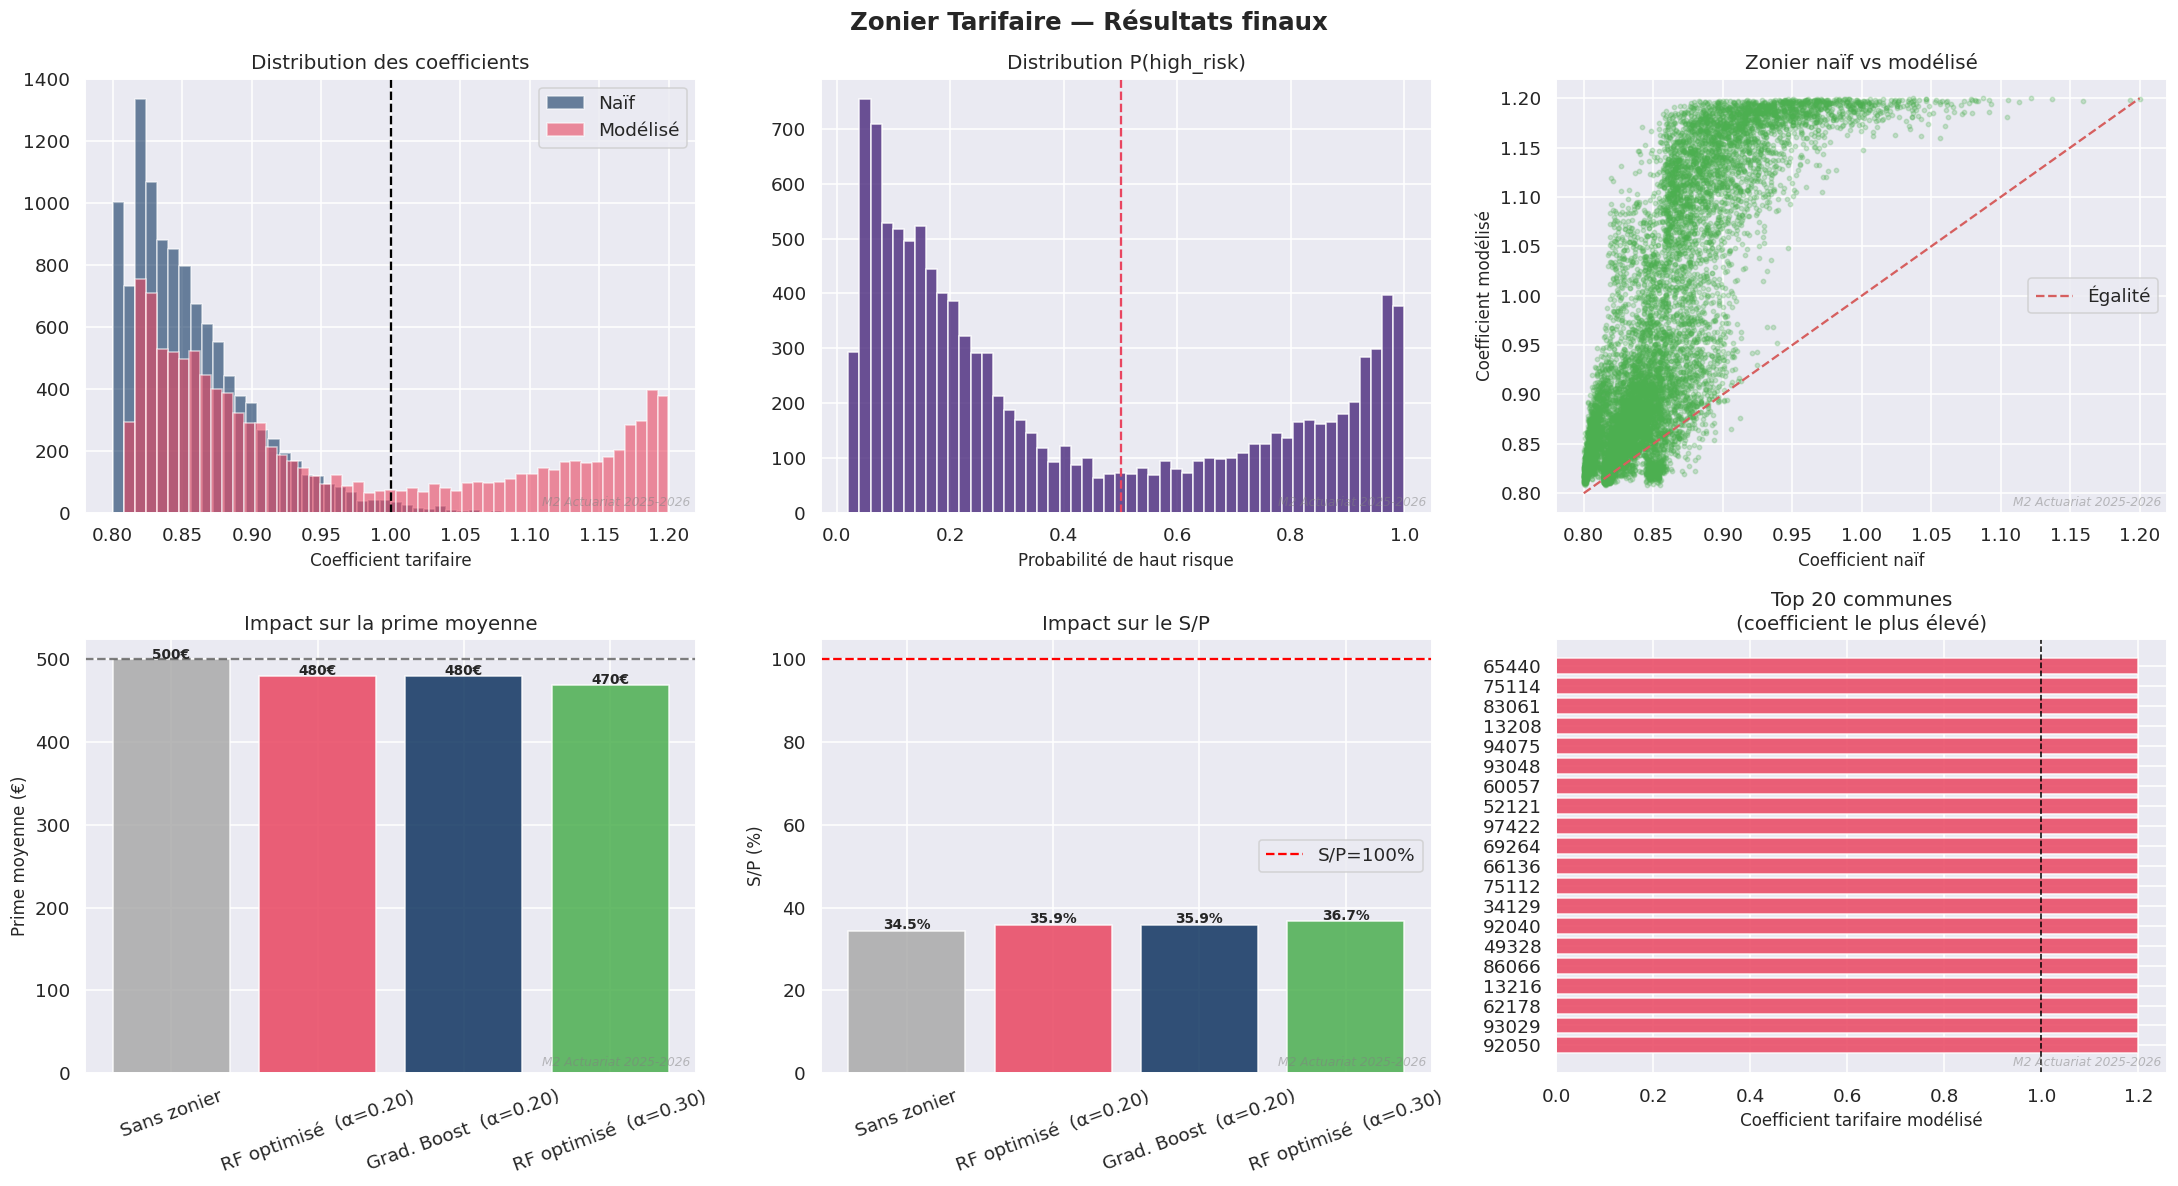

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Zonier Tarifaire — Résultats finaux", fontsize=16, fontweight='bold')

# 1. Distribution coefficients
axes[0,0].hist(df_final['coeff_naif'],     bins=50, alpha=0.6,
               color='#0f3460', label='Naïf', edgecolor='white')
axes[0,0].hist(df_final['coeff_modelise'], bins=50, alpha=0.6,
               color='#e94560', label='Modélisé', edgecolor='white')
axes[0,0].axvline(1.0, color='black', linewidth=1.5, linestyle='--')
axes[0,0].set_title("Distribution des coefficients")
axes[0,0].set_xlabel("Coefficient tarifaire")
axes[0,0].legend()
watermark(axes[0,0])

# 2. Distribution P(high_risk)
axes[0,1].hist(df_final['P_high_risk'], bins=50, color='#533483', edgecolor='white', alpha=0.85)
axes[0,1].axvline(0.5, color='#e94560', linestyle='--', linewidth=1.5)
axes[0,1].set_title("Distribution P(high_risk)")
axes[0,1].set_xlabel("Probabilité de haut risque")
watermark(axes[0,1])

# 3. Naif vs Modelise
axes[0,2].scatter(df_final['coeff_naif'], df_final['coeff_modelise'],
                  alpha=0.25, s=8, color='#4caf50')
mn = df_final[['coeff_naif','coeff_modelise']].min().min()
mx = df_final[['coeff_naif','coeff_modelise']].max().max()
axes[0,2].plot([mn,mx],[mn,mx],'r--', linewidth=1.5, label='Égalité')
axes[0,2].set_title("Zonier naïf vs modélisé")
axes[0,2].set_xlabel("Coefficient naïf")
axes[0,2].set_ylabel("Coefficient modélisé")
axes[0,2].legend()
watermark(axes[0,2])

# 4. Impact prime
labels_b = ['Sans zonier'] + [s['label'] for s in sensibilite]
primes_b = [PRIME_BASELINE] + [s['prime_moy'] for s in sensibilite]
bars = axes[1,0].bar(labels_b, primes_b,
                      color=['#aaa','#e94560','#0f3460','#4caf50'],
                      edgecolor='white', alpha=0.85)
axes[1,0].axhline(PRIME_BASELINE, color='black', linestyle='--', alpha=0.5)
axes[1,0].set_title("Impact sur la prime moyenne")
axes[1,0].set_ylabel("Prime moyenne (€)")
axes[1,0].tick_params(axis='x', rotation=20)
for bar in bars:
    h = bar.get_height()
    axes[1,0].text(bar.get_x()+bar.get_width()/2., h+1, f'{h:.0f}€',
                   ha='center', fontsize=9, fontweight='bold')
watermark(axes[1,0])

# 5. S/P
sp_base = pf['cout_sin'].sum() / (pf['prime_baseline'].sum())
sp_all  = [sp_base] + [s['sp'] for s in sensibilite]
axes[1,1].bar(labels_b, [v*100 for v in sp_all],
              color=['#aaa','#e94560','#0f3460','#4caf50'],
              edgecolor='white', alpha=0.85)
axes[1,1].axhline(100, color='red', linestyle='--', linewidth=1.5, label='S/P=100%')
axes[1,1].set_title("Impact sur le S/P")
axes[1,1].set_ylabel("S/P (%)")
axes[1,1].tick_params(axis='x', rotation=20)
for i, v in enumerate(sp_all):
    axes[1,1].text(i, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1,1].legend()
watermark(axes[1,1])

# 6. Top 20 communes les plus risquées
ax6 = axes[1,2]
top20 = df_final.nlargest(20,'coeff_modelise').sort_values('coeff_modelise')
ax6.barh(top20['code_commune'], top20['coeff_modelise'],
         color='#e94560', edgecolor='white', alpha=0.85)
ax6.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax6.set_title("Top 20 communes\n(coefficient le plus élevé)")
ax6.set_xlabel("Coefficient tarifaire modélisé")
watermark(ax6)

plt.tight_layout()
plt.show()

---
<div style="background:linear-gradient(135deg,#1a1a2e 0%,#0f3460 100%);
     padding:40px 35px;border-radius:14px;margin-top:20px;">
<h2 style="color:#e94560;text-align:center;">Synthèse & Conclusions</h2>
<hr style="border:1px solid #e94560;width:50%;margin:15px auto;">
<div style="color:#fff;line-height:2.0;">

<p><b style="color:#a8dadc;">Partie 1 — PySpark (étapes 1–8)</b><br>
Chargement des 4 fichiers BAAC 2023 via <code>spark.read.csv()</code>.
Jointures PySpark (<code>join</code>), agrégations (<code>groupBy/agg</code>),
création des indicateurs de risque avec <code>withColumn/F.when</code>.
Agrégation par commune, détection des communes de transit, enrichissement INSEE.
Score de sinistralité calculé en PySpark, transformé et normalisé sans data leakage.
</p>

<p><b style="color:#a8dadc;">Partie 2 — Analyse de données II (étapes 8–9)</b><br>
Matrice de corrélations et identification de la multicolinéarité.
ACP sur {n_comp80} composantes (80% variance) pour décorrélation.
Régression linéaire (score_norm) et logistique (score_bin) sur features brutes et axes ACP.
</p>

<p><b style="color:#a8dadc;">Partie 3 — ML & Optimisation stochastique (étapes 10–12)</b><br>
Batch GD et SGD implémentés manuellement, comparés à SGDRegressor sklearn.
7 modèles de classification comparés sur toutes les métriques.
Random Forest optimisé par RandomizedSearchCV, validé en CV 5-fold.
Explicabilité par permutation importance + SHAP. Sélection RFE.
</p>

<p><b style="color:#a8dadc;">Partie 4 — Zonier tarifaire (étape 13)</b><br>
Coefficients tarifaires calculés via predict_proba (formule 1+α(2P−1)).
Comparaison zonier naïf vs modélisé.
Analyse de sensibilité sur 3 configurations (modèle, α).
Impact calculé sur prime moyenne et S/P d'un portefeuille fictif de 10 000 contrats.
</p>

</div>
</div>